# ESP32 Data Logger — Notebook 



## Setup

In [3]:

# === Setup ===
import os, glob, re, io, hashlib, scipy, yaml, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

from typing import Any, Dict, List, Tuple, Optional, Sequence

from logger_tools import ensure_datetime_index, resample_df, ema, moving_average, LinearCal, segment_by_marks
import importlib



# Display options
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## Config

In [4]:

# File locations
DATA_DIR = r"C:\Users\benco\OneDrive\Documents\BODAQS\logs" 
GLOB = "2025-10-25*.CSV"           
SCHEMA_PATH = "event_schema.yaml"

# File offsets - set True only when concatenating multiple *independent* files
ADD_FILE_OFFSETS = True   

LOCAL_TZ = "Australia/Perth"  # convert from UTC to your local time (optional)

# Work-around for dodgy data: columns to de-spike
COLS_TO_CLEAN = ["rear_shock [mm]", "front_shock [mm]"]

#Sample rates
SAMPLE_RATE_HZ = 200
RESAMPLE_HZ = 50

# Normalisation
NORMALIZE_RANGES = {"front_shock [mm]": 170.0, "rear_shock [mm]":  165.0,}
OUTPUT_SUFFIX_ZEROED = "_zeroed"
OUTPUT_SUFFIX_NORM   = "_norm"
CLIP_0_1             = False
ADD_ZEROED_COLUMN    = True

# Zeroing control
ZEROING_ENABLED      = False        # <--- Turn this off to skip zeroing (offset = 0)
ZERO_WINDOW_S        = 1.0
ZERO_USE_MEDIAN      = False
ZERO_PER_SEGMENT     = True
TIME_COL_CANDIDATES  = ("t","time_s","time","timestamp","datetime")
MIN_SAMPLES_ABS_MIN  = 10

# Velocity and Acceleration
VA_DISPLACEMENT_COLS = ["rear_shock [mm]", "front_shock [mm]"]

    # Savitzky–Golay parameters
WINDOW_POINTS = 11      # must be odd; typical 7–21
POLY_ORDER    = 3       # < window_points; typical 2–4

    # Suffixes for outputs
VEL_SUFFIX = "_vel"
ACC_SUFFIX = "_acc"

# Trim inactive segments
ACTIVE_DISP_COL = "rear_shock [mm]"     # or "front_shock [mm]_norm"
ACTIVE_VEL_COL  = "rear_shock [mm]_vel"    # or "front_shock_vel [mm/s]"
ACTIVE_DISP_THRESH = 20.0    # below this (normalized units), considered at-rest
ACTIVE_VEL_THRESH  = 50.0     # below this (mm/s), considered at-rest
ACTIVE_WINDOW       = "500ms"    # rolling window to smooth the activity mask
ACTIVE_PADDING      = "1s"       # keep context before/after active segments
ACTIVE_MIN_SEGMENT  = "3s"       # discard very short bursts




## Load files

In [5]:
# === Load (robust clock parsing, no float math, per-file offset optional) ===

def load_logger_csv(path: str) -> pd.DataFrame:
    # Read raw text and clean
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.replace("\0", "").strip() for ln in f if ln.strip()]

    # Detect delimiter
    sample = "".join(lines[:5])
    delim = "," if sample.count(",") > sample.count(";") else ";"

    df = pd.read_csv(
        path,
        sep=delim,
        comment="#",
        engine="python",
        on_bad_lines="skip",
    )

    # Convert timestamp to seconds (float) robustly
    if "timestamp" in df.columns:
        t0 = pd.to_datetime(df["timestamp"], format="%H:%M:%S.%f", errors="coerce")
        df = df.loc[t0.notna()].copy()
        df["t"] = (t0 - t0.iloc[0]).dt.total_seconds().astype(np.float64)

    # Clean numeric columns
    for c in df.columns:
        if c != "timestamp":
            df[c] = (
                df[c]
                .astype(str)
                .str.replace(r"[^0-9eE+\-\.]", "", regex=True)
                .replace("", np.nan)
                .astype(float)
            )

    # Drop NaNs and deduplicate by time
    df = df.dropna().drop_duplicates(subset="t", keep="first").reset_index(drop=True)
    df = df[df["t"].diff().fillna(0) >= 0]  # keep monotonic time
    return df

def ensure_time_index(df: pd.DataFrame) -> pd.DataFrame:
    import pandas as pd

    out = df.copy()
    if isinstance(out.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        pass
    elif "t" in out.columns:
        out.index = pd.to_timedelta(out["t"].astype(float), unit="s")
        out.index.name = "t"
        out = out.drop(columns=["t"])     # ✅ remove duplicate column
    elif "timestamp" in out.columns:
        dt = pd.to_datetime(out["timestamp"], errors="coerce")
        out = out.loc[dt.notna()]
        out.index = dt
    else:
        raise TypeError("No 't' or 'timestamp' column to build a time index from.")

    # make sure index is clean
    out = out.sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out

def parse_clock_column_to_datetime(s: pd.Series) -> pd.Series:
    """
    Parse 'HH:MM:SS.mmm' or 'MM:SS.mmm' (commas or dots) to pandas datetime64[ns]
    on a dummy date, vectorized and without float arithmetic.
    """
    s = s.astype(str).str.strip().str.replace(",", ".", regex=False)

    # Identify 2-part vs 3-part times
    parts = s.str.split(":", n=2, expand=True)
    n_parts = parts.shape[1]

    # Build a normalized 'HH:MM:SS.mmm' string
    if n_parts == 2:
        # MM:SS(.mmm)
        mm = parts[0].str.zfill(2)
        ss = parts[1]
        norm = "00:" + mm + ":" + ss
    elif n_parts == 3:
        # HH:MM:SS(.mmm)
        hh = parts[0].str.zfill(2)
        mm = parts[1].str.zfill(2)
        ss = parts[2]
        norm = hh + ":" + mm + ":" + ss
    else:
        raise ValueError("Unexpected clock format; expected MM:SS(.ms) or HH:MM:SS(.ms)")

    # Ensure milliseconds have at least 3 digits if present
    # e.g. '12:34:56.7' -> '12:34:56.700'
    has_frac = norm.str.contains(r"\.")
    def pad_ms(x: str) -> str:
        if "." not in x: return x
        hms, frac = x.split(".", 1)
        # keep up to microseconds to be safe, pad to 3-6
        frac = (frac + "000000")[:6]
        return hms + "." + frac

    norm = pd.Series(np.where(has_frac, norm.map(pad_ms), norm), index=norm.index)

    # Use a dummy date so we can take accurate timedeltas (no float)
    dt = pd.to_datetime("1970-01-01 " + norm, format="%Y-%m-%d %H:%M:%S.%f", errors="raise")
    return dt

files = sorted(glob.glob(os.path.join(DATA_DIR, GLOB)))
if not files:
    raise SystemExit(f"No files matched: {os.path.join(DATA_DIR, GLOB)}")

dfs = []
cumulative_offset = pd.Timedelta(0)
for fp in files:
    raw = load_logger_csv(fp)

    # Find timestamp column (case-insensitive), else first column
    cols_lower = {c.lower(): c for c in raw.columns}
    ts_col = cols_lower.get("timestamp", raw.columns[0])

    # Parse to datetime64[ns] on dummy date
    dt = parse_clock_column_to_datetime(raw[ts_col])

    # Make per-file times relative to *first row* (no float)
    rel = dt - dt.iloc[0]

    # Optionally apply cross-file offset so each file starts after previous
    if ADD_FILE_OFFSETS and len(dfs) > 0:
        rel = rel + cumulative_offset

    df = raw.drop(columns=[ts_col])

    # convert numerics
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except (ValueError, TypeError):
            continue
    # set TimedeltaIndex and sort
    df = df.set_index(rel).sort_index()

    # collapse true duplicates within this file, if any
    dup_count = int(df.index.duplicated().sum())
    if dup_count:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        non_num = [c for c in df.columns if c not in num_cols]
        agg = {c: "mean" for c in num_cols}
        agg.update({c: "first" for c in non_num})
        counts = df.groupby(level=0).size().rename("samples_merged")
        df = df.groupby(level=0).agg(agg).join(counts)

    # add numeric t (seconds)
    df["t"] = df.index.total_seconds()

    # update cumulative offset for next file
    if ADD_FILE_OFFSETS:
        cumulative_offset = df.index[-1] + (df.index[-1] - df.index[-2] if len(df) > 1 else pd.Timedelta(0))

    print(f"Loaded {os.path.basename(fp)} rows={len(df):,}  dup_in_file={dup_count}")

    dfs.append(df)

# Concatenate (already sorted & relative)
data = pd.concat(dfs).sort_index()

# Final dedupe across all (paranoia)
all_dups = int(data.index.duplicated().sum())
if all_dups:
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    non_num = [c for c in data.columns if c not in num_cols]
    agg = {c: "mean" for c in num_cols}
    agg.update({c: "first" for c in non_num})
    counts = data.groupby(level=0).size().rename("samples_merged_all")
    data = data.groupby(level=0).agg(agg).join(counts)

# Ensure time index
data = ensure_time_index(data)


# Diagnostics
print(f"\nCombined rows: {len(data):,} | duplicates_after_concat={all_dups}")
print("Index type:", type(data.index).__name__)
print("Index sample:", data.index[:5])
print("\nHead(10):")
print(data.head(10).to_string())

# dt diagnostics (no float in parsing, but diff is float; inspect only >0)
t = data.index.view("i8")  # ns as int64
dt_ns = np.diff(t)
pos = dt_ns[dt_ns > 0]
nonpos_frac = 1.0 - (len(pos) / max(1, len(dt_ns)))
med_dt = np.median(pos) if len(pos) else np.nan
print(f"\nMedian dt: {med_dt/1e9 if np.isfinite(med_dt) else np.nan:.6f}s | nonpositive dt frac: {nonpos_frac:.3%}")

# Ranges
numeric_cols = data.select_dtypes(include=[np.number]).columns
if len(numeric_cols):
    print("\nColumn value ranges (numeric columns only):")
    stats = (data[numeric_cols].agg(['min','max']).T).sort_index()
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo numeric columns found to show min/max.")
data.to_csv("df_after_load.csv", index=False)


Loaded 2025-10-25_12-19-17_cashout.CSV rows=371,328  dup_in_file=0
Loaded 2025-10-25_12-56-07_sendit.CSV rows=186,665  dup_in_file=0
Loaded 2025-10-25_14-11-17_sendit.CSV rows=104,368  dup_in_file=0
Loaded 2025-10-25_14-39-03_sendit.CSV rows=77,550  dup_in_file=0
Loaded 2025-10-25_16-03-42_blackglove.CSV rows=158,982  dup_in_file=0
Loaded 2025-10-25_16-43-36_damit.CSV rows=78,044  dup_in_file=0

Combined rows: 976,937 | duplicates_after_concat=0
Index type: TimedeltaIndex
Index sample: TimedeltaIndex([       '0 days 00:00:00', '0 days 00:00:00.005000', '0 days 00:00:00.010000', '0 days 00:00:00.015000',
                '0 days 00:00:00.020000'],
               dtype='timedelta64[ns]', freq=None)

Head(10):
                        front_shock [mm]  front_shock_raw [counts]  rear_shock [mm]  rear_shock_raw [counts]  mark      t
0 days 00:00:00                 6.103398                     491.0              0.0                    151.0   0.0  0.000
0 days 00:00:00.005000          6.053777

## Work-around for dodgy data

In [6]:
# === Spike fix (multi-series, interpolate bad samples, keep raw) ===
# Uses the same simple prev/next-jump rule you had, but per column.
# - Copies raw columns to "<col>_raw"
# - Sets flagged samples to NaN, interpolates only those points
# - Adds "<col>_interp_flag" (bool) so you can QA or compute % interpolated later


# --- Config ---
# Either a single threshold (mm) for all cols, or a dict {col: threshold}
cols = COLS_TO_CLEAN    
threshold = 20  # or: {"rear_shock [mm]": 15, "front_shock [mm]": 12}

# Prefer shape-preserving 'pchip' if SciPy available; else fallback to 'linear'
_interp_method = "pchip"
try:
    # quick runtime check: pandas will raise if method unsupported
    pd.Series([0.0, np.nan, 1.0]).interpolate(method=_interp_method)
except Exception:
    _interp_method = "linear"

total_flagged = 0
total_len = len(data)

for col in cols:
    if col not in data.columns:
        print(f"[warn] Column not found: {col} — skipping")
        continue

    thr = threshold[col] if isinstance(threshold, dict) else float(threshold)

    # Keep a pristine copy
    raw_col = f"{col}_raw"
    if raw_col not in data.columns:  # avoid duplicating if re-running
        data[raw_col] = data[col]

    # Jumps to previous/next samples (same as your logic)
    prev_jump = data[col].diff().abs()
    next_jump = data[col].diff(-1).abs()

    # Smooth on both sides => good; otherwise bad (and not already NaN)
    good_mask = (prev_jump < thr) & (next_jump < thr)
    bad_mask = (~good_mask) & data[col].notna()

    # Interpolate only where bad: set to NaN -> interpolate -> put back
    s = data[col].astype(float).copy()
    s[bad_mask] = np.nan

    # Interpolate across gaps; allow both directions so edge spikes get something reasonable
    s_interp = s.interpolate(method=_interp_method, limit_direction="both")

    # Optional: if you prefer not to extrapolate at edges, comment the line above and
    # use this pair instead:
    # s_interp = s.interpolate(method=_interp_method, limit_area="inside")
    # s_interp = s_interp.fillna(method="bfill").fillna(method="ffill")

    # Record which bad points were actually replaced
    interp_flag = bad_mask & s_interp.notna()

    # Commit cleaned series and flag
    data[col] = s_interp
    data[f"{col}_interp_flag"] = interp_flag

    n_bad = int(bad_mask.sum())
    n_fixed = int(interp_flag.sum())
    total_flagged += n_bad
    print(f"[{col}] flagged {n_bad} ({n_bad/len(data)*100:.3f}%), filled {n_fixed} via '{_interp_method}'")

print(f"Total flagged across all series: {total_flagged} / {total_len*len(cols)} samples "
      f"({(total_flagged/(total_len*len(cols)) if total_len and cols else 0)*100:.3f}%)")


[rear_shock [mm]] flagged 1074 (0.110%), filled 1074 via 'pchip'
[front_shock [mm]] flagged 988 (0.101%), filled 988 via 'pchip'
Total flagged across all series: 2062 / 1953874 samples (0.106%)


## Normalise

In [7]:
# === Normalize by optional "lowest 1-second average" zeroing, then divide by user full-range ===

if "data" not in globals():
    raise RuntimeError("Expected 'data' from the Load cell. Run Load first.")

df = data.copy()

# ---- helpers ----
def _find_time_col(frame: pd.DataFrame):
    for c in TIME_COL_CANDIDATES:
        if c in frame.columns:
            return c
    if isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return None
    return None

def _ensure_time_seconds(frame: pd.DataFrame, tcol: str | None):
    if tcol and tcol in frame.columns:
        s = frame[tcol]
        if np.issubdtype(s.dtype, np.number):
            return s.to_numpy(dtype=float)
        try:
            dt = pd.to_datetime(s, errors="coerce")
            if not dt.isna().all():
                t0 = dt.iloc[0]
                return (dt - t0).dt.total_seconds().to_numpy()
        except Exception:
            pass
    idx = frame.index
    if isinstance(idx, pd.DatetimeIndex):
        return (idx - idx[0]).total_seconds()
    if isinstance(idx, pd.TimedeltaIndex):
        return (idx - idx[0]).total_seconds()
    n = len(frame)
    return np.arange(n, dtype=float) if n > 1 else np.array([0.0])

def _median_dt_seconds(t: np.ndarray):
    dt = np.diff(t)
    dt = dt[(dt > 0) & np.isfinite(dt)]
    return float(np.median(dt)) if dt.size else np.nan

def _min_window_avg_offset(seg_df: pd.DataFrame, value_col: str, t_s: np.ndarray,
                           window_s: float, use_median: bool, min_samples: int):
    y = pd.to_numeric(seg_df[value_col], errors="coerce").to_numpy()
    ok = np.isfinite(t_s) & np.isfinite(y)
    t = t_s[ok]; y = y[ok]
    if t.size == 0:
        return None
    order = np.argsort(t)
    t = t[order]; y = y[order]
    i = 0
    best_val, best_i, best_j = np.inf, None, None
    for j in range(len(t)):
        while t[j] - t[i] > window_s and i < j:
            i += 1
        count = j - i + 1
        if count >= min_samples:
            w = y[i:j+1]
            val = float(np.median(w)) if use_median else float(np.mean(w))
            if val < best_val:
                best_val, best_i, best_j = val, i, j
    if best_i is None:
        return None
    return {
        "offset": best_val,
        "t_start": float(t[best_i]),
        "t_end": float(t[best_j]),
        "n_samples": int(best_j - best_i + 1),
    }

# Prepare time base
tcol = _find_time_col(df)
t_s = _ensure_time_seconds(df, tcol)
dt_est = _median_dt_seconds(t_s)
min_samples = max(MIN_SAMPLES_ABS_MIN,
                  int(np.ceil(ZERO_WINDOW_S / (dt_est if np.isfinite(dt_est) and dt_est > 0 else 0.01))))

norm_report = []
segments = df["segment_id"].unique() if (ZERO_PER_SEGMENT and "segment_id" in df.columns) else [None]

for col, full_range in NORMALIZE_RANGES.items():
    if col not in df.columns:
        print(f"[skip] '{col}' not found in data columns.")
        continue

    s = pd.to_numeric(df[col], errors="coerce")
    if s.dropna().empty:
        print(f"[skip] '{col}' has no numeric data.")
        continue

    if ZEROING_ENABLED:
        best = {"offset": np.inf, "seg": None}
        for seg in segments:
            seg_mask = (df["segment_id"] == seg) if (seg is not None) else np.ones(len(df), dtype=bool)
            res = _min_window_avg_offset(df.loc[seg_mask], col, t_s[seg_mask],
                                         ZERO_WINDOW_S, ZERO_USE_MEDIAN, min_samples)
            if res and res["offset"] < best["offset"]:
                best.update(res); best["seg"] = seg
        if not np.isfinite(best["offset"]):
            offset = float(s.min(skipna=True))
            method = "min_fallback"
        else:
            offset = float(best["offset"])
            method = "min_1s_median" if ZERO_USE_MEDIAN else "min_1s_mean"
    else:
        offset = 0.0
        method = "zeroing_disabled"

    zeroed = s - offset
    norm = zeroed / float(full_range)
    if CLIP_0_1:
        norm = norm.clip(0.0, 1.0)

    if ADD_ZEROED_COLUMN:
        df[col + OUTPUT_SUFFIX_ZEROED] = zeroed
    df[col + OUTPUT_SUFFIX_NORM] = norm

    norm_report.append({
        "column": col,
        "zeroing_enabled": ZEROING_ENABLED,
        "offset(method)": method,
        "offset": offset,
        "full_range": float(full_range),
        "coverage": float(zeroed.max(skipna=True)) / float(full_range),
    })

data = df

print("Normalization complete. Added columns:")
for col in NORMALIZE_RANGES:
    if col in df.columns:
        if ADD_ZEROED_COLUMN:
            print(f"  - {col+OUTPUT_SUFFIX_ZEROED}")
        print(f"  - {col+OUTPUT_SUFFIX_NORM}")

# Summary
rep = pd.DataFrame(norm_report).set_index("column")
try:
    display(rep)
except Exception:
    print(rep.to_string())

# Show min / max per numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols):
    print("\nColumn value ranges (numeric columns only):")
    stats = (
        df[numeric_cols]
        .agg(["min", "max"])
        .T  # transpose for readability
        .sort_index()
    )
    # Optional: round for clarity
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo numeric columns found to show min/max.")

# more diagnostics
print(data.dtypes)                               # see if 'rear_shock [mm]' is object
print(data['rear_shock [mm]'].head(5))           # any non-numeric text?
print(pd.to_numeric(data['rear_shock [mm]'], errors='coerce').isna().mean())

data.to_csv("df_after_normalise.csv", index=False)


Normalization complete. Added columns:
  - front_shock [mm]_zeroed
  - front_shock [mm]_norm
  - rear_shock [mm]_zeroed
  - rear_shock [mm]_norm


,zeroing_enabled,offset(method),offset,full_range,coverage
column,,,,,
front_shock [mm],False,zeroing_disabled,0.0,170.0,0.836554
rear_shock [mm],False,zeroing_disabled,0.0,165.0,0.900077



Column value ranges (numeric columns only):
                                min        max
front_shock [mm]            -0.5458   142.2141
front_shock [mm]_norm       -0.0032     0.8366
front_shock [mm]_raw        -0.5458   142.2141
front_shock [mm]_zeroed     -0.5458   142.2141
front_shock_raw [counts]   357.0000  3234.0000
mark                         0.0000     1.0000
rear_shock [mm]              0.0000   148.5127
rear_shock [mm]_norm         0.0000     0.9001
rear_shock [mm]_raw          0.0000   148.5127
rear_shock [mm]_zeroed       0.0000   148.5127
rear_shock_raw [counts]     37.0000  2715.0000
t                            0.0000  4884.6800
front_shock [mm]                float64
front_shock_raw [counts]        float64
rear_shock [mm]                 float64
rear_shock_raw [counts]         float64
mark                            float64
                                 ...   
front_shock [mm]_interp_flag       bool
front_shock [mm]_zeroed         float64
front_shock [mm]_norm   

## Velocity and Acceleration

In [8]:
# --- Config ---
# Columns to process (zeroed displacement columns). If None, auto-detect numeric, non-time columns.
cols = VA_DISPLACEMENT_COLS

# Sampling: either set sample_rate_hz OR ensure your index is DatetimeIndex OR there is a 'time_s' column.
sample_rate_hz   = SAMPLE_RATE_HZ
time_column_name = "time_s"  # set to None if deriving from DatetimeIndex

# Savitzky–Golay parameters
window_points = WINDOW_POINTS
poly_order    = POLY_ORDER


# Try SciPy; if missing, we’ll use a NumPy fallback
try:
    from scipy.signal import savgol_filter
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _infer_dt(df, sample_rate_hz=None, time_col="time_s"):
    """Infer dt (s) from explicit sample rate, a time column, or a DatetimeIndex."""
    if sample_rate_hz is not None:
        return 1.0 / float(sample_rate_hz)
    # try explicit time column
    if time_col and time_col in df.columns:
        t = pd.to_numeric(df[time_col], errors="coerce").to_numpy()
        dt = np.median(np.diff(t))
        if np.isfinite(dt) and dt > 0:
            return float(dt)
    # try a common alternative name
    if "t" in df.columns:
        t = pd.to_numeric(df["t"], errors="coerce").to_numpy()
        d = np.diff(t)
        d = d[(d > 0) & np.isfinite(d)]
        if d.size:
            return float(np.median(d))
    # try DatetimeIndex
    if isinstance(df.index, pd.DatetimeIndex):
        dt = pd.Series(df.index).diff().dt.total_seconds().median()
        if np.isfinite(dt) and dt > 0:
            return float(dt)
    raise ValueError("Cannot infer dt. Provide sample_rate_hz or a valid time column or DatetimeIndex.")

def _pick_cols(df, cols):
    """Pick numeric columns to process, excluding obvious time-like columns."""
    if cols is not None:
        return list(cols)
    drop_like = {"time", "timestamp", "date"}
    cands = []
    for c in df.select_dtypes(include=[np.number]).columns:
        lc = c.lower()
        if any(k in lc for k in drop_like):
            continue
        cands.append(c)
    if not cands:
        raise ValueError("No numeric columns found to process. Set 'cols' explicitly.")
    return cands

def _validate_params(window_points, poly_order):
    if window_points % 2 == 0:
        raise ValueError("window_points must be odd.")
    if poly_order >= window_points:
        raise ValueError("poly_order must be < window_points.")
    if poly_order < 1:
        raise ValueError("poly_order should be >= 1.")

def _savgol_numpy(y, window_points, poly_order, deriv, dt):
    """
    Minimal SG fallback using NumPy:
    - Build local polynomial basis (centered window),
    - Convolve with derivative coefficients,
    - Reflect-pad edges.
    """
    n = len(y)
    if n < window_points:
        # shrink to nearest odd <= n (keeps behaviour sane on very short slices)
        window_points = max(3, (n // 2) * 2 + 1)
        if poly_order >= window_points:
            poly_order = max(1, window_points - 1)

    half = window_points // 2
    x = np.arange(-half, half + 1, dtype=float)
    A = np.vander(x, N=poly_order + 1, increasing=True)  # columns: x^0..x^p
    pinv = np.linalg.pinv(A)
    coeff = pinv[deriv, :] * np.math.factorial(deriv)     # derivative at x=0
    scale = (dt ** (-deriv))

    # Reflect-pad
    left  = y[1:half+1][::-1] if n > 1 else np.array([y[0]] * half)
    right = y[-half-1:-1][::-1] if n > 1 else np.array([y[-1]] * half)
    ypad = np.r_[left, y, right]
    filt = np.convolve(ypad, coeff[::-1], mode="valid") * scale
    return filt

def estimate_va_from_zeroed(df,
                            cols=None,
                            sample_rate_hz=None,
                            time_col="time_s",
                            window_points=11,
                            poly_order=3,
                            vel_suffix=VEL_SUFFIX,
                            acc_suffix=ACC_SUFFIX):
    _validate_params(window_points, poly_order)
    dt = _infer_dt(df, sample_rate_hz=sample_rate_hz, time_col=time_col)
    target_cols = _pick_cols(df, cols)

    out = df.copy()
    # interpolate numeric gaps gently
    data = out[target_cols].apply(pd.to_numeric, errors="coerce").interpolate(limit_direction="both")

    for c in target_cols:
        y = data[c].to_numpy()
        if _HAVE_SCIPY:
            v = savgol_filter(y, window_points, poly_order, deriv=1, delta=dt, mode="interp")
            a = savgol_filter(y, window_points, poly_order, deriv=2, delta=dt, mode="interp")
        else:
            v = _savgol_numpy(y, window_points, poly_order, deriv=1, dt=dt)
            a = _savgol_numpy(y, window_points, poly_order, deriv=2, dt=dt)
        out[c + vel_suffix] = v
        out[c + acc_suffix] = a

    return out, {"dt": dt, "window_points": window_points, "poly_order": poly_order, "cols": target_cols}

# ---- Run on the "data" dataframe ----
df_src = data
src_name = "data"

df_va, meta_va = estimate_va_from_zeroed(
    df_src,
    cols=cols,
    sample_rate_hz=sample_rate_hz,
    time_col=time_column_name,
    window_points=window_points,
    poly_order=poly_order,
)

# Expose result under a convenient global name, e.g. "data_va" if source was "data"
out_name = f"{src_name}"
globals()[out_name] = df_va
df_va  # also leave it as the last expression for notebook display

print(
    f"[VA] Source='{src_name}' → Output='{out_name}'. "
    f"Cols={meta_va['cols']}, dt={meta_va['dt']:.6f}s, "
    f"window={meta_va['window_points']}, order={meta_va['poly_order']}"
)


[VA] Source='data' → Output='data'. Cols=['rear_shock [mm]', 'front_shock [mm]'], dt=0.005000s, window=11, order=3


## Generic plot cell

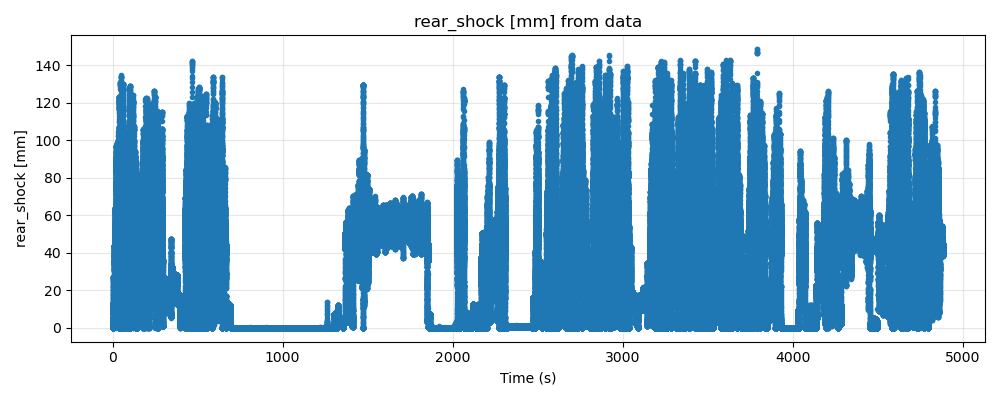

In [9]:
import pandas as pd

# === CONFIG ===
df_name = "data"       # name of dataframe (string)
col_name = "rear_shock [mm]"   # column to plot
title = None                        # optional custom title (None = auto)

# --- Retrieve dataframe from globals ---
if df_name not in globals():
    raise RuntimeError(f"DataFrame '{df_name}' not found in globals().")

df = globals()[df_name]
if col_name not in df.columns:
    raise KeyError(f"Column '{col_name}' not found in {df_name}.")

# --- Determine x-axis ---
if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    x = df.index.total_seconds() if isinstance(df.index, pd.TimedeltaIndex) else df.index
    xlabel = "Time (s)" if isinstance(df.index, pd.TimedeltaIndex) else "Timestamp"
elif "t" in df.columns:
    x = df["t"]
    xlabel = "Time (s)"
else:
    x = df.index
    xlabel = "Sample #"

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(x, df[col_name], ".")
plt.xlabel(xlabel)
plt.ylabel(col_name)
plt.title(title or f"{col_name} from {df_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Trim inactive sections

In [10]:
# === Trim inactive sections based on displacement *and* velocity thresholds ===
frame = data.copy()

frame = ensure_time_index(frame)  # ensure TimedeltaIndex or DatetimeIndex

if not isinstance(frame.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    raise TypeError("Expected a time-based index (Timedelta/Datetime).")

# ---------- CONFIG ----------
DISP_COL = "rear_shock [mm]"     # or "front_shock [mm]_norm"
VEL_COL  = "rear_shock [mm]_vel"    # or "front_shock_vel [mm/s]"
DISP_THRESH = 20.0    # below this (normalized units), considered at-rest
VEL_THRESH  = 50.0     # below this (mm/s), considered at-rest
WINDOW       = "500ms"    # rolling window to smooth the activity mask
PADDING      = "1s"       # keep context before/after active segments
MIN_SEGMENT  = "3s"       # discard very short bursts
# ---------------------------

if ACTIVE_DISP_COL not in frame.columns or ACTIVE_VEL_COL not in frame.columns:
    raise ValueError(f"Expected columns {ACTIVE_DISP_COL!r} and {ACTIVE_VEL_COL!r} in {frame}")

# activity = either displacement or velocity exceeds threshold
disp_active = frame[ACTIVE_DISP_COL].abs() > ACTIVE_DISP_THRESH
vel_active  = frame[ACTIVE_VEL_COL].abs()  > ACTIVE_VEL_THRESH
active_mask = disp_active & vel_active

# rolling “softening” of the mask to prevent flicker
active_mask = active_mask.rolling(ACTIVE_WINDOW, min_periods=1).max().astype(bool)

pad    = pd.to_timedelta(ACTIVE_PADDING)
minseg = pd.to_timedelta(ACTIVE_MIN_SEGMENT)

# find contiguous active segments
segments = []
if active_mask.any():
    block_id = (active_mask != active_mask.shift(fill_value=False)).cumsum()
    for _, g in active_mask.groupby(block_id):
        if not g.iloc[0]:
            continue
        s = g.index[0] - pad
        e = g.index[-1] + pad
        segments.append([s, e])
    # merge overlaps
    segments.sort(key=lambda x: x[0])
    merged = []
    for s, e in segments:
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)
    # drop short ones
    merged = [[s, e] for s, e in merged if (e - s) >= minseg]
else:
    merged = []

# apply mask to keep only merged segments
if merged:
    keep = pd.Series(False, index=frame.index)
    for s, e in merged:
        keep |= (frame.index >= s) & (frame.index <= e)
    data_active = frame.loc[keep].copy()
    segments_active = [frame.loc[(frame.index >= s) & (frame.index <= e)].copy() for s, e in merged]
else:
    data_active = frame.iloc[0:0].copy()
    segments_active = []

print(f"Active segments kept: {len(merged)}")
for i, (s, e) in enumerate(merged, 1):
    print(f"  {i:02d}: {s} → {e}  (duration {(e - s)})")
print("Rows in original:", len(frame), " | Rows kept:", len(data_active))

# Quick summary
if len(data_active):
    print("\nColumn ranges in active data:")
    stats = (
        data_active.select_dtypes(include=[np.number])
        .agg(["min", "max"])
        .T
        .sort_index()
    )
    with pd.option_context("display.float_format", "{:10.4f}".format):
        print(stats.to_string())
else:
    print("\nNo active data found.")

data_active.to_csv("df_data_active.csv", index=False)


Active segments kept: 54
  01: 0 days 00:00:03.675000 → 0 days 00:00:09.410000  (duration 0 days 00:00:05.735000)
  02: 0 days 00:00:13.715000 → 0 days 00:02:21.535000  (duration 0 days 00:02:07.820000)
  03: 0 days 00:02:38.615000 → 0 days 00:04:57.170000  (duration 0 days 00:02:18.555000)
  04: 0 days 00:05:16.390000 → 0 days 00:05:19.435000  (duration 0 days 00:00:03.045000)
  05: 0 days 00:05:34.345000 → 0 days 00:05:38.485000  (duration 0 days 00:00:04.140000)
  06: 0 days 00:05:41.615000 → 0 days 00:05:45.635000  (duration 0 days 00:00:04.020000)
  07: 0 days 00:07:04.805000 → 0 days 00:11:06.350000  (duration 0 days 00:04:01.545000)
  08: 0 days 00:22:45.315000 → 0 days 00:22:49.180000  (duration 0 days 00:00:03.865000)
  09: 0 days 00:22:50.875000 → 0 days 00:22:56.575000  (duration 0 days 00:00:05.700000)
  10: 0 days 00:22:59.690000 → 0 days 00:23:22.680000  (duration 0 days 00:00:22.990000)
  11: 0 days 00:23:30.045000 → 0 days 00:30:52.260000  (duration 0 days 00:07:22.2150

## Resample

In [11]:

if RESAMPLE_HZ:
   # data = ensure_time_index(data)                      # make t (s) the TimedeltaIndex
    data_active_rs = resample_df(data_active, rate_hz=RESAMPLE_HZ, how="mean")
    print(f"Resampled to {RESAMPLE_HZ} Hz: {len(data_active_rs):,} rows")
else:
    data_active_rs = data_active.copy()


Resampled to 50 Hz: 243,634 rows


## Generic plot cell

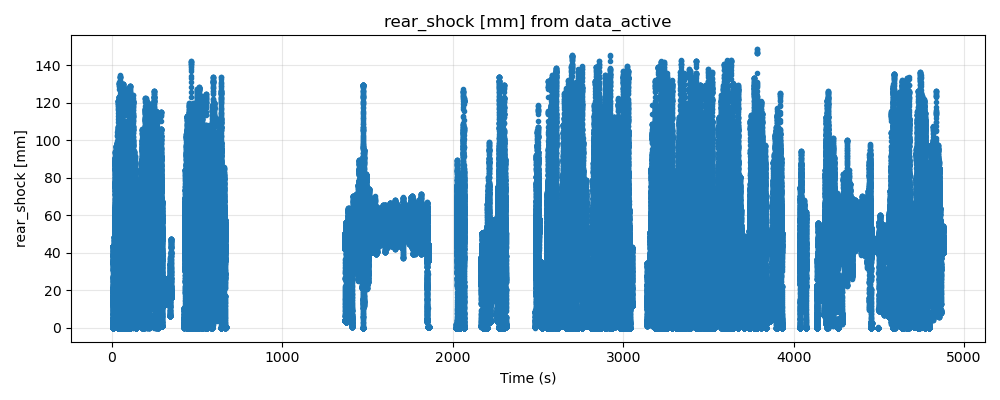

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# === CONFIG ===
df_name = "data_active"       # name of dataframe (string)
col_name = "rear_shock [mm]"   # column to plot
title = None                        # optional custom title (None = auto)

# --- Retrieve dataframe from globals ---
if df_name not in globals():
    raise RuntimeError(f"DataFrame '{df_name}' not found in globals().")

df = globals()[df_name]
if col_name not in df.columns:
    raise KeyError(f"Column '{col_name}' not found in {df_name}.")

# --- Determine x-axis ---
if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
    x = df.index.total_seconds() if isinstance(df.index, pd.TimedeltaIndex) else df.index
    xlabel = "Time (s)" if isinstance(df.index, pd.TimedeltaIndex) else "Timestamp"
elif "t" in df.columns:
    x = df["t"]
    xlabel = "Time (s)"
else:
    x = df.index
    xlabel = "Sample #"

# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(x, df[col_name], ".")
plt.xlabel(xlabel)
plt.ylabel(col_name)
plt.title(title or f"{col_name} from {df_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Config for event analysis: explicitly set columns and data frame

In [13]:
INPUT_FRAME   = "data_active"   # e.g. "data", "data_rs", "data_active", "data_active_va"
INPUT_COLUMNS = [
    "front_shock [mm]",       # displacement    
    "front_shock [mm]_vel",   # velocity
    "front_shock [mm]_acc",   # acceleration
    "front_shock [mm]_norm",   # normalised displacement
    "rear_shock [mm]",        # displacement
    "rear_shock [mm]_vel",    # velocity
    "rear_shock [mm]_acc",    # acceleration
    "rear_shock [mm]_norm",    # normalised displacement

]
OUTPUT_NAME   = "event_analysis_df"
META_NAME     = "event_analysis_meta"

SKIP_EVENTS = {}

# Time repair / gap marking parameters (used only if a clean 't' isn't already present)
DT_HINT = None       # e.g., 0.01 for 100 Hz; None = infer
GAP_FACTOR = 10.0    # gap if Δt > GAP_FACTOR * median(Δt)
GAP_MIN_S  = None    # or absolute gap threshold (e.g., 0.2)
MIN_STEP_FACTOR = 0.5  # when repairing backsteps, insert at least MIN_STEP_FACTOR*dt_hint

# --- Helpers (lightweight, local) ---
def _derive_time_seconds(df: pd.DataFrame) -> np.ndarray:
    # Prefer numeric time column if present
    for c in ("t", "time_s"):
        if c in df.columns and np.issubdtype(df[c].dtype, np.number):
            return df[c].to_numpy(dtype=float)
    # Otherwise try common timestamp names
    for c in ("timestamp", "time"):
        if c in df.columns:
            s = df[c]
            if np.issubdtype(s.dtype, np.datetime64) or s.dtype == object:
                dt = pd.to_datetime(s, utc=False, errors="coerce")
                if dt.isna().all():
                    continue
                t0 = dt.iloc[0]
                return (dt - t0).dt.total_seconds().to_numpy()
    # Fallback: datetime-like index
    idx = df.index
    if isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return (idx - idx[0]).total_seconds()
    # Last resort: unit steps (we'll still compute dt)
    n = len(df)
    if n > 1:
        return np.arange(n, dtype=float)
    raise RuntimeError("Could not infer time base: provide a 't' or 'time_s' column, or a datetime index.")

def _repair_monotonic(t: np.ndarray, dt_hint=None, min_step_factor=0.5):
    t = np.asarray(t, dtype=float).copy()
    diffs = np.diff(t)
    if dt_hint is None:
        finite = diffs[np.isfinite(diffs)]
        if finite.size:
            finite_pos = finite[(finite > 0) & (finite < np.nanpercentile(finite, 95))]
            median_dt = float(np.nanmedian(finite_pos)) if finite_pos.size else 0.0
        else:
            median_dt = 0.0
    else:
        median_dt = float(dt_hint)
    min_step = median_dt * float(min_step_factor) if median_dt > 0 else 0.0

    bumps = 0
    total_added = 0.0
    for i in range(1, len(t)):
        if t[i] + 1e-12 < t[i-1]:
            bump = (t[i-1] - t[i]) + (min_step if min_step > 0 else 0.0)
            t[i:] += bump
            total_added += bump
            bumps += 1
    return t, bumps, total_added, median_dt

def _mark_gaps(t: np.ndarray, gap_factor=10.0, gap_min_s=None):
    dt = np.diff(t, prepend=t[0])
    finite = dt[np.isfinite(dt)]
    med = float(np.nanmedian(finite[finite > 0])) if np.any(finite > 0) else 0.0
    thr = max(gap_min_s or 0.0, (gap_factor * med) if med > 0 else 0.0)
    gap_mask = (dt > thr) if thr > 0 else np.zeros_like(dt, dtype=bool)
    gap_mask[0] = False
    segment_id = np.cumsum(gap_mask).astype(int)
    return gap_mask, segment_id, thr

def _insert_plot_breaks(df: pd.DataFrame, gap_mask: np.ndarray, value_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    if value_cols:
        num_cols = [c for c in value_cols if not pd.api.types.is_bool_dtype(out[c])]
        out.loc[gap_mask, num_cols] = np.nan
    return out

# --- Implementation ---
obj = globals().get(INPUT_FRAME, None)
if not isinstance(obj, pd.DataFrame) or obj.empty:
    raise RuntimeError(f"Input frame '{INPUT_FRAME}' not found or empty. Check that you loaded your data.")

missing = [c for c in INPUT_COLUMNS if c not in obj.columns]
if missing:
    raise RuntimeError(f"Missing columns in '{INPUT_FRAME}': {missing}")

# 1) Build/verify time column 't'
had_t = "t" in obj.columns and np.issubdtype(obj["t"].dtype, np.number)
t0 = obj["t"].to_numpy(dtype=float) if had_t else _derive_time_seconds(obj)
t_fixed, n_back, added, inferred_dt = _repair_monotonic(t0, dt_hint=DT_HINT, min_step_factor=MIN_STEP_FACTOR)

# 2) Mark large gaps and build segment_id (only matters for plotting/inspection)
gap_mask, segment_id, gap_thr = _mark_gaps(t_fixed, gap_factor=GAP_FACTOR, gap_min_s=GAP_MIN_S)

# 3) Create a working copy of the source with clean time metadata
src = obj.copy()
if "t_raw" not in src.columns:
    src["t_raw"] = t0
src["t"] = t_fixed
src["segment_id"] = segment_id
src["time_backstep_flag"] = False
if n_back > 0:
    back_flag = np.zeros(len(src), dtype=bool)
    back_flag[1:] = np.diff(t0) < 0
    src["time_backstep_flag"] = back_flag

# 4) Build a plot-safe view that breaks lines at gaps
value_cols = [c for c in src.columns if c not in ("t","t_raw","segment_id","time_backstep_flag")]
plot_view = _insert_plot_breaks(src, gap_mask, value_cols=value_cols)
globals()[f"plot_view_{INPUT_FRAME}"] = plot_view  # convenience for quick plotting

# 5) Assemble the minimal analysis frame (selected columns + clean 't')
event_analysis_df = src[INPUT_COLUMNS + ["t"]].copy()
event_analysis_df = ensure_time_index(event_analysis_df)


# 6) Compute robust dt (median spacing on the fixed time)
dt = float(np.nanmedian(np.diff(event_analysis_df["t"].to_numpy()))) if len(event_analysis_df) > 1 else None

# 7) Register globals
globals()[OUTPUT_NAME] = event_analysis_df
globals()[META_NAME] = {
    "source": INPUT_FRAME,
    "columns": INPUT_COLUMNS,
    "dt": dt,
    "nrows": len(event_analysis_df),
    "n_backsteps_repaired": int(n_back),
    "total_seconds_added": float(added),
    "gap_threshold_s": float(gap_thr),
}

# 8) Status
print(f"[Config] Using {INPUT_FRAME} with {len(event_analysis_df)} rows → {OUTPUT_NAME}")
print("Columns:", ", ".join(event_analysis_df.columns))
if dt:
    print(f"Derived dt ≈ {dt:.6f} s (inferred base dt ≈ {inferred_dt:.6f} s)")
if n_back > 0:
    print(f"[TimeFix] Repaired {n_back} backward step(s); total +{added:.6f} s added.")
print(f"[TimeFix] Gap threshold ≈ {gap_thr:.6g} s; segments = {int(segment_id.max()+1)}")
print(f"Plot-safe view available as: plot_view_{INPUT_FRAME}")

#event_analysis_df.to_csv("event_analysis_df_data.csv", index=False)


[Config] Using data_active with 595101 rows → event_analysis_df
Columns: front_shock [mm], front_shock [mm]_vel, front_shock [mm]_acc, front_shock [mm]_norm, rear_shock [mm], rear_shock [mm]_vel, rear_shock [mm]_acc, rear_shock [mm]_norm, t
Derived dt ≈ 0.005000 s (inferred base dt ≈ 0.005000 s)
[TimeFix] Gap threshold ≈ 0.05 s; segments = 54
Plot-safe view available as: plot_view_data_active


## Load and validate event schema

In [14]:
import io
import hashlib
from typing import Dict, Any, List, Tuple, Optional

import yaml
import pandas as pd

# ---- Helpers ----
def _read_file_bytes(path: str) -> bytes:
    with open(path, "rb") as f:
        return f.read()

def _sha256(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def load_event_schema(path: str) -> Tuple[Dict[str, Any], str]:
    data_bytes = _read_file_bytes(path)
    h = _sha256(data_bytes)
    schema = yaml.safe_load(io.BytesIO(data_bytes))
    if not isinstance(schema, dict):
        raise ValueError("Top-level YAML must be a mapping (dict).")
    return schema, h

def _validate_debounce_block(prefix: str, deb: Any, issues: List[str]):
    """Validate a debounce mapping: {gap_s, prefer_key, prefer_abs, prefer_max}."""
    if deb is None:
        return
    if not isinstance(deb, dict):
        issues.append(f"{prefix}.debounce must be a mapping if present.")
        return
    gap = deb.get("gap_s", None)
    if gap is not None and not isinstance(gap, (int, float)):
        issues.append(f"{prefix}.debounce.gap_s must be a number (seconds) if present.")
    pref_key = deb.get("prefer_key", None)
    if pref_key is not None and not isinstance(pref_key, str):
        issues.append(f"{prefix}.debounce.prefer_key must be a string if present.")
    pref_abs = deb.get("prefer_abs", None)
    if pref_abs is not None and not isinstance(pref_abs, bool):
        issues.append(f"{prefix}.debounce.prefer_abs must be a boolean if present.")
    pref_max = deb.get("prefer_max", None)
    if pref_max is not None and not isinstance(pref_max, bool):
        issues.append(f"{prefix}.debounce.prefer_max must be a boolean if present.")

def basic_validate(schema: Dict[str, Any]) -> List[str]:
    """Lightweight sanity checks; returns a list of issues (empty if OK)."""
    issues: List[str] = []

    # ---- defaults & naming ----
    defaults = schema.get("defaults", {}) or {}
    if not isinstance(defaults, dict):
        issues.append("defaults must be a mapping if present.")

    # deprecated global debounce_s
    if "debounce_s" in defaults:
        issues.append("defaults.debounce_s is deprecated; use defaults.debounce.gap_s instead.")

    def_debounce = defaults.get("debounce", None)
    if def_debounce is not None and not isinstance(def_debounce, dict):
        issues.append("defaults.debounce must be a mapping if present.")
    else:
        _validate_debounce_block("defaults", def_debounce, issues)

    naming = schema.get("naming", {}) or {}
    if naming and not isinstance(naming, dict):
        issues.append("naming must be a mapping if present.")

    suffixes = (naming.get("suffixes") or {}) if isinstance(naming, dict) else {}
    if not isinstance(suffixes, dict):
        issues.append("naming.suffixes must be a mapping of kind→suffix.")
        suffixes = {}
    if not suffixes:
        issues.append("naming.suffixes is empty or missing (suffix-only schema expects at least disp/vel/acc).")
    else:
        for k in ("disp", "vel", "acc"):
            if k not in suffixes:
                issues.append(f"naming.suffixes missing expected key '{k}' (disp/vel/acc).")

    # ---- events list ----
    events = schema.get("events")
    if not isinstance(events, list) or not events:
        issues.append("Missing or empty 'events' list.")
        return issues

    allowed_trigger_types = {
        "local_extrema",
        "simple_threshold_crossing",
        "threshold_crossing",
        "zero_crossing",
        "phased_threshold_crossing",
        "custom",
    }
    allowed_dirs = {"rising", "falling", "either"}

    for i, ev in enumerate(events):
        prefix = f"events[{i}]"
        if not isinstance(ev, dict):
            issues.append(f"{prefix}: must be a mapping.")
            continue

        # ---- sensors (suffix-only design requires them) ----
        sensors = ev.get("sensors", None)
        if not (isinstance(sensors, list) and sensors and all(isinstance(s, str) and s for s in sensors)):
            issues.append(f"{prefix}.sensors must be a non-empty list of strings.")

        # deprecated event-level debounce
        if "debounce" in ev:
            issues.append(f"{prefix}.debounce is deprecated; move debounce under trigger/debounce for each trigger.")
        if "debounce_s" in ev:
            issues.append(f"{prefix}.debounce_s is deprecated; use trigger.debounce.gap_s instead.")

        # ---- primary trigger ----
        trig = ev.get("trigger", None)
        if trig is None:
            issues.append(f"{prefix}: missing required key 'trigger'.")
            continue
        if not isinstance(trig, dict):
            issues.append(f"{prefix}.trigger must be a mapping.")
            continue

        ttype = trig.get("type")
        tsig  = trig.get("signal")
        tdir  = trig.get("dir", None)

        if ttype not in allowed_trigger_types:
            issues.append(f"{prefix}.trigger.type '{ttype}' not in allowed set {sorted(allowed_trigger_types)}.")
        if ttype != "custom" and not isinstance(tsig, str):
            issues.append(f"{prefix}.trigger.signal must be a string for non-custom triggers.")

        if ttype in ("simple_threshold_crossing", "threshold_crossing", "zero_crossing", "phased_threshold_crossing"):
            if tdir is not None and tdir not in allowed_dirs:
                issues.append(f"{prefix}.trigger.dir '{tdir}' must be one of {sorted(allowed_dirs)}.")

        # per-trigger debounce
        _validate_debounce_block(f"{prefix}.trigger", trig.get("debounce", None), issues)

        # ---- secondary triggers ----
        sec_trigs = ev.get("secondary_triggers", None)
        if sec_trigs is not None:
            if not isinstance(sec_trigs, list):
                issues.append(f"{prefix}.secondary_triggers must be a list if present.")
            else:
                for j, st in enumerate(sec_trigs):
                    sprefix = f"{prefix}.secondary_triggers[{j}]"
                    if not isinstance(st, dict):
                        issues.append(f"{sprefix}: must be a mapping.")
                        continue
                    sid  = st.get("id")
                    stype = st.get("type")
                    ssig = st.get("signal")

                    if not isinstance(sid, str) or not sid:
                        issues.append(f"{sprefix}.id must be a non-empty string.")
                    if stype not in allowed_trigger_types:
                        issues.append(f"{sprefix}.type '{stype}' not in allowed set {sorted(allowed_trigger_types)}.")
                    if stype != "custom" and not isinstance(ssig, str):
                        issues.append(f"{sprefix}.signal must be a string for non-custom triggers.")

                    _validate_debounce_block(f"{sprefix}", st.get("debounce", None), issues)

        # ---- window & debounce (event-level window still valid) ----
        win = ev.get("window", None)
        if win is not None and not isinstance(win, dict):
            issues.append(f"{prefix}.window must be a mapping if present.")

        # ---- basic metrics shape ----
        metrics = ev.get("metrics", None)
        if metrics is not None:
            if not isinstance(metrics, list):
                issues.append(f"{prefix}.metrics must be a list if present.")
            else:
                for j, m in enumerate(metrics):
                    mprefix = f"{prefix}.metrics[{j}]"
                    if not isinstance(m, dict):
                        issues.append(f"{mprefix}: must be a mapping.")
                        continue
                    mtype = m.get("type")
                    if not isinstance(mtype, str):
                        issues.append(f"{mprefix}.type must be a string.")
                    if mtype == "interval_stats":
                        # not strictly required, but helpful to flag obvious mistakes
                        if "end_trigger" not in m:
                            issues.append(f"{mprefix}: interval_stats should specify 'end_trigger'.")

    return issues


def summarize_events(schema: Dict[str, Any]) -> pd.DataFrame:
    """
    Create a concise per-event summary table, including:
      - primary trigger type/signal/dir/value
      - sensors
      - window (pre_s/post_s/align)
      - primary debounce gap_s
      - secondary trigger IDs
    """
    rows = []

    defaults = schema.get("defaults", {}) or {}
    def_window = defaults.get("window", {}) or {}
    def_pre   = def_window.get("pre_s", None)
    def_post  = def_window.get("post_s", None)
    def_align = def_window.get("align", None)

    def_debounce = (defaults.get("debounce") or {})
    def_gap_s    = def_debounce.get("gap_s", None)
    def_pref_key = def_debounce.get("prefer_key", None)
    def_pref_abs = def_debounce.get("prefer_abs", None)
    def_pref_max = def_debounce.get("prefer_max", None)

    for ev in schema.get("events", []) or []:
        trig = ev.get("trigger", {}) or {}
        ttype = trig.get("type")
        tsig  = trig.get("signal")
        tdir  = trig.get("dir") or trig.get("kind")  # kind for local_extrema
        tvalue = trig.get("value")

        # window (with defaults)
        window = ev.get("window", {}) or {}
        pre = window.get("pre_s",  def_pre)
        post = window.get("post_s", def_post)
        align = window.get("align", def_align)

        # debounce: per-trigger, falling back to defaults
        tdeb = trig.get("debounce", {}) or {}
        gap_s = tdeb.get("gap_s", def_gap_s)
        prefer_key = tdeb.get("prefer_key", def_pref_key)
        prefer_abs = tdeb.get("prefer_abs", def_pref_abs)
        prefer_max = tdeb.get("prefer_max", def_pref_max)

        metrics = ev.get("metrics", []) or []

        sensors = ev.get("sensors", [])
        sensors_str = ", ".join(sensors) if isinstance(sensors, list) else ""

        sec_trigs = ev.get("secondary_triggers", []) or []
        secondary_ids = ", ".join(
            str(st.get("id")) for st in sec_trigs
            if isinstance(st, dict) and st.get("id")
        )

        rows.append({
            "id": ev.get("id"),
            "label": ev.get("label"),
            "sensors": sensors_str,
            "trigger_type": ttype,
            "trigger_signal": tsig,
            "trigger_dir/kind": tdir,
            "trigger_value": tvalue,
            "pre_s": pre,
            "post_s": post,
            "align": align,
            "primary_gap_s": gap_s,
            "primary_prefer_key": prefer_key,
            "primary_prefer_abs": prefer_abs,
            "primary_prefer_max": prefer_max,
            "n_secondary_triggers": len(sec_trigs),
            "secondary_ids": secondary_ids,
            "n_metrics": len(metrics),
        })

    cols = [
        "id", "label", "sensors",
        "trigger_type", "trigger_signal", "trigger_dir/kind", "trigger_value",
        "pre_s", "post_s", "align",
        "primary_gap_s", "primary_prefer_key", "primary_prefer_abs", "primary_prefer_max",
        "n_secondary_triggers", "secondary_ids",
        "n_metrics",
    ]
    return pd.DataFrame(rows, columns=cols)


# ---- Execute: load, validate, summarize ----
schema, schema_hash = load_event_schema(SCHEMA_PATH)
issues = basic_validate(schema)
summary_df = summarize_events(schema)

print(f"Loaded event schema from: {SCHEMA_PATH}")
print(f"Schema version: {schema.get('version','(none)')}")
print(f"Events defined: {len(schema.get('events', []))}")
print(f"SHA256: {schema_hash}")
print("\nSchema passed basic validation." if not issues else "\nVALIDATION ISSUES:\n - " + "\n - ".join(issues))

# Optional: display a compact table (works nicely in notebooks)
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Event Schema Summary", summary_df)
except Exception:
    display(summary_df)

# Expose globals for later cells
EVENT_SCHEMA = schema
EVENT_SCHEMA_HASH = schema_hash
EVENT_SCHEMA_SUMMARY = summary_df


Loaded event schema from: event_schema.yaml
Schema version: 3
Events defined: 2
SHA256: 5124c5fa6bdaae1ed6c24942d40c8a5b403180ed51cc86d3a658aa470b5cc16e

Schema passed basic validation.


,id,label,sensors,trigger_type,trigger_signal,trigger_dir/kind,trigger_value,pre_s,post_s,align,primary_gap_s,primary_prefer_key,primary_prefer_abs,primary_prefer_max,n_secondary_triggers,secondary_ids,n_metrics
0,deep_compression,deep compression (0.8 <= disp_norm < 0.98),"rear_shock, front_shock",local_extrema,disp,max,NaN,0.2,0.8,trigger,0.3,disp,False,True,0,,0
1,rebounds,all rebound events >0.4,"rear_shock, front_shock",simple_threshold_crossing,vel,falling,0.0,0.2,0.8,trigger,0.3,disp,False,True,1,rebound_end,2


## Build events table

In [15]:
# Optional SciPy peak detection (more robust prominence/distance handling)
try:
    from scipy.signal import find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

MIN_PROMINENCE = 1
SMOOTH_MS = 50  # not heavily used, kept for future smoothing options

# ---------------- Basics & helpers ----------------

def _require_inputs():
    """
    Return (event_analysis_df, event_analysis_meta, EVENT_SCHEMA).
    Falls back sensibly if meta/schema aren't present yet.
    """
    # DataFrame
    df = globals().get("event_analysis_df", None)
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise RuntimeError("Missing 'event_analysis_df'. Run the analysis config cell that creates it.")

    # Meta
    meta = globals().get("event_analysis_meta", None)
    if not isinstance(meta, dict):
        # build a lightweight meta on the fly
        dt = np.nan
        if "t" in df.columns and len(df) > 1:
            d = np.diff(pd.to_numeric(df["t"], errors="coerce"))
            d = d[(d > 0) & np.isfinite(d)]
            if d.size:
                dt = float(np.median(d))
        meta = {"source": "(unknown)", "columns": list(df.columns), "dt": dt, "nrows": len(df)}
        globals()["event_analysis_meta"] = meta  # expose for later

    # Schema
    schema = globals().get("EVENT_SCHEMA", None)
    if not isinstance(schema, dict) or not schema:
        raise RuntimeError("Missing 'EVENT_SCHEMA'. Load your YAML schema into EVENT_SCHEMA before running detection.")

    return df, meta, schema


def _to_seconds(series: pd.Series) -> np.ndarray:
    """Return time in seconds as float64 from a numeric/Timedelta/Datetime series."""
    s = series
    dt = s.dtype

    # Handle Timedelta64[ns]
    if np.issubdtype(dt, np.timedelta64):
        return s.astype("timedelta64[ns]").view("int64") / 1e9

    # Handle Datetime64[ns]
    if np.issubdtype(dt, np.datetime64):
        base = s.astype("datetime64[ns]").view("int64")[0]
        return (s.astype("datetime64[ns]").view("int64") - base) / 1e9

    # Already numeric → assume seconds
    return pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)


def _robust_dt(df: pd.DataFrame, meta: dict) -> float:
    """Try meta['dt'], else estimate from 't' column."""
    dt_val = float(meta.get("dt", np.nan))
    if np.isfinite(dt_val) and dt_val > 0:
        return dt_val
    if "t" in df.columns and len(df) > 1:
        t_sec = _to_seconds(df["t"])
        diffs = np.diff(t_sec)
        diffs = diffs[(diffs > 0) & np.isfinite(diffs)]
        if diffs.size:
            return float(np.median(diffs))
    return float("nan")


def _sec_to_samples_opt(s: float | None, dt: float) -> int | None:
    """Seconds → samples; returns None if dt invalid or s is None."""
    if s is None:
        return None
    if not np.isfinite(dt) or dt <= 0:
        return None
    return int(round(float(s) / float(dt)))


def _clip_bounds(n: int, i0: int, i1: int):
    return max(0, i0), min(n, i1)


def _series_get(df: pd.DataFrame, name: str):
    if not name:
        raise KeyError("Series name is None — check trigger.signal and suffix mapping.")
    if name not in df.columns:
        raise KeyError(f"Series '{name}' not found in event_analysis_df columns.")
    return df[name].to_numpy()


def _nan_frac(arr):
    return float(np.mean(np.isnan(arr))) if arr.size else 1.0

def _resolve_search_window(trig: dict, t: np.ndarray, base_t0_sec: float | None):
    """
    Return (i0, i1) index bounds into t for trigger search.

    Semantics:
      - If trig.search is absent/empty and base_t0_sec is None/invalid → whole series [0, n)
      - Otherwise:
          * base time = base_t0_sec (if finite) else t[0]
          * start = base + min_delay_s
          * end   = base + max_delay_s (or last time if max_delay_s missing)
    """
    search = trig.get("search") or {}
    n = len(t)
    if n == 0:
        return 0, 0

    if not search and (base_t0_sec is None or not np.isfinite(base_t0_sec)):
        return 0, n

    min_delay_s = float(search.get("min_delay_s", 0.0))
    max_delay_s = search.get("max_delay_s", None)

    if base_t0_sec is None or not np.isfinite(base_t0_sec):
        base = float(t[0])
    else:
        base = float(base_t0_sec)

    start_sec = base + min_delay_s
    end_sec   = base + float(max_delay_s) if max_delay_s is not None else float(t[-1])

    i0 = int(np.searchsorted(t, start_sec, side="left"))
    i1 = int(np.searchsorted(t, end_sec,   side="right"))
    return _clip_bounds(n, i0, i1)


# ---------- inputs resolver & validation ----------

def _resolve_inputs_for_sensor(sensor: str, schema: dict) -> dict:
    """
    Build an explicit mapping {kind -> column name} for a given sensor,
    purely from naming.suffixes (suffix-only design).
    """
    naming = schema.get("naming", {}) or {}
    suffixes = (naming.get("suffixes") or {})
    out = {}
    for kind, suf in suffixes.items():
        if sensor:
            out[kind] = f"{sensor}{suf}"
    return out


def _expand_event_by_sensors(ev: dict, schema: dict) -> list[dict]:
    """
    Turn one (multi-sensor) event into a list of per-sensor events,
    each with an explicit 'sensor'. Suffix-only: we no longer support
    legacy single-sensor events without 'sensors'.
    """
    sensors = ev.get("sensors") or []
    if not sensors:
        raise KeyError(f"Event '{ev.get('id','?')}' missing 'sensors' in suffix-only schema.")
    out = []
    for s in sensors:
        ev2 = dict(ev)
        ev2["sensor"] = s
        out.append(ev2)
    return out


def _validate_event_series_with_map(ev: dict, df: pd.DataFrame, inputs_map: dict):
    """
    Validate that trigger/conditions/metrics refer to signals present in `inputs_map`,
    and that the mapped DataFrame columns exist.
    """
    ev_id = ev.get("id", "(unknown)")
    trig = ev.get("trigger", {}) or {}

    # ---- Trigger ----
    sig = trig.get("signal")
    if sig:
        if sig not in inputs_map:
            raise KeyError(
                f"Event '{ev_id}': trigger.signal='{sig}' not found in resolved inputs_map keys {list(inputs_map.keys())}."
            )
        col = inputs_map[sig]
        if col not in df.columns:
            raise KeyError(
                f"Event '{ev_id}': trigger.signal '{sig}' maps to column '{col}', "
                f"which is not in event_analysis_df."
            )

    # ---- Collect referenced signals in conditions & metrics ----
    def _collect_refs(blocks):
        refs = set()
        for blk in (blocks or []):
            for key in ("any_of", "all_of"):
                for test in (blk.get(key) or []):
                    s = test.get("signal")
                    if s:
                        refs.add(s)
        return refs

    cond_refs   = _collect_refs(ev.get("preconditions")) | _collect_refs(ev.get("postconditions"))
    metric_refs = {m.get("signal") for m in (ev.get("metrics") or []) if m.get("signal")}
    needed      = {x for x in (cond_refs | metric_refs) if x}

    # ---- Validate each referenced signal via the resolved mapping ----
    for name in needed:
        if name not in inputs_map:
            raise KeyError(
                f"Event '{ev_id}': a condition/metric references '{name}', "
                f"but resolved inputs_map only has {list(inputs_map.keys())}."
            )
        col = inputs_map[name]
        if col not in df.columns:
            raise KeyError(
                f"Event '{ev_id}': signal '{name}' maps to column '{col}', "
                f"which is not in event_analysis_df."
            )


# ---------------- Triggers ----------------

def _trigger_local_extrema(df, dt, ev, base_t0_sec=None):
    trig = ev["trigger"]
    signal = trig.get("signal")            # 'disp' | 'vel' | 'acc'
    kind = trig.get("kind")                # 'min' | 'max'
    prom = trig.get("prominence")          # units of the chosen series
    dist_s = trig.get("distance_s")
    edge_ignore_s = trig.get("edge_ignore_s")

    series_name = ev["inputs"].get(signal)
    y = _series_get(df, series_name).copy()
    t = _to_seconds(df["t"])
    n = len(y)
    if n == 0:
        return []

    # base series (peaks operate on this)
    if kind == "min":
        y_proc = -y
        prom_arg = prom if prom is None else float(prom)
    else:
        y_proc = y
        prom_arg = prom if prom is None else float(prom)

    distance = _sec_to_samples_opt(dist_s, dt)

    # edge ignore in samples
    edge = _sec_to_samples_opt(edge_ignore_s, dt) or 0

    # search window (for secondary vs primary)
    i0, i1 = _resolve_search_window(trig, t, base_t0_sec)
    if i0 >= i1:
        return []

    # clamp window to edge-ignore region
    search_lo = max(edge, i0)
    search_hi = min(n - edge, i1)
    if search_lo >= search_hi:
        return []

    if _HAVE_SCIPY:
        y_sub = y_proc[search_lo:search_hi]
        kwargs = {}
        if prom_arg is not None:
            kwargs["prominence"] = prom_arg
        if (distance is not None) and (distance > 1):
            kwargs["distance"] = int(distance)
        idx_local, props = find_peaks(y_sub, **kwargs)
        prominences = props.get("prominences", np.full_like(idx_local, np.nan, dtype=float)) if props else np.full(0, np.nan)
        idx = idx_local + search_lo
    else:
        idx = np.arange(search_lo + 1, search_hi - 1)
        prominences = []
        kept = []
        if kind == "min":
            cand = idx[(y[idx] < y[idx-1]) & (y[idx] <= y[idx+1])]
            win = max(5, int(distance) if distance else 5)
            for i in cand:
                L = max(0, i-win); R = min(n, i+win+1)
                ref = np.nanmax(y[L:R])
                p = (ref - y[i])
                if prom is None or (p >= prom):
                    kept.append(i); prominences.append(p)
        else:
            cand = idx[(y[idx] > y[idx-1]) & (y[idx] >= y[idx+1])]
            win = max(5, int(distance) if distance else 5)
            for i in cand:
                L = max(0, i-win); R = min(n, i+win+1)
                ref = np.nanmin(y[L:R])
                p = (y[i] - ref)
                if prom is None or (p >= prom):
                    kept.append(i); prominences.append(p)
        idx = np.array(kept, dtype=int)
        prominences = np.array(prominences, dtype=float)

    # Package
    out = []
    for i, p in zip(idx, prominences if len(prominences) else [np.nan]*len(idx)):
        out.append({
            "t0_index": int(i),
            "t0_time": float(t[i]),
            "trigger_strength": float(p) if np.isfinite(p) else None,
            "trigger_value": float(y[i]) if np.isfinite(y[i]) else None,
        })
    return out



def _trigger_threshold_crossing(df, dt, ev, base_t0_sec=None):
    """
    Implements 'simple_threshold_crossing' (and legacy 'threshold_crossing').

    When base_t0_sec is not None and trigger.search is present,
    restricts search to that time window (used for secondary triggers).
    """
    trig = ev["trigger"]
    signal = trig.get("signal")
    if not signal:
        return []

    direction = trig.get("dir", "either")
    value = float(trig.get("value", 0.0))
    hyster = float(trig.get("hysteresis", 0.0))

    series_name = ev["inputs"].get(signal)   # e.g. 'rear_shock [mm]_vel'
    y = _series_get(df, series_name).astype(float)
    t = _to_seconds(df["t"])
    n = len(y)
    if n == 0:
        return []

    # optional displacement for scoring
    disp_col = ev["inputs"].get("disp")
    if disp_col:
        x_raw = _series_get(df, disp_col)
        x = np.asarray(x_raw, dtype=float)
    else:
        x = None

    # search window
    i0, i1 = _resolve_search_window(trig, t, base_t0_sec)
    if i0 >= i1:
        return []

    crossings = []
    armed_rising = True
    armed_falling = True

    for i in range(max(1, i0), i1):
        y0, y1 = y[i-1], y[i]

        if direction in ("rising", "either"):
            if armed_rising and (y0 < value) and (y1 >= value):
                crossings.append(i)
                armed_rising = False
            if (y1 <= value - hyster):
                armed_rising = True

        if direction in ("falling", "either"):
            if armed_falling and (y0 > value) and (y1 <= value):
                crossings.append(i)
                armed_falling = False
            if (y1 >= value + hyster):
                armed_falling = True

    crossings = np.unique(np.asarray(crossings, dtype=int))

    out = []
    for i in crossings:
        d = {
            "t0_index": int(i),
            "t0_time": float(t[i]),
            "trigger_value": float(y[i]),
            "trigger_strength": float(abs(y[i] - y[i-1])) if i > 0 and np.isfinite(y[i-1]) else None,
        }
        if x is not None and 0 <= i < len(x) and np.isfinite(x[i]):
            d["disp"] = float(x[i])
        out.append(d)

    return out



def _trigger_zero_crossing(df, dt, ev, base_t0_sec=None):
    trig = ev["trigger"].copy()
    trig.setdefault("value", 0.0)
    ev2 = dict(ev); ev2["trigger"] = trig
    return _trigger_threshold_crossing(df, dt, ev2, base_t0_sec=base_t0_sec)



def _trigger_phased_threshold_crossing(df, dt, ev, base_t0_sec=None):
    """
    Phased threshold crossing trigger.

    Looks for a NEG → ZERO → POS (for dir='rising') or
    POS → ZERO → NEG (for dir='falling') pattern in the chosen signal,
    constrained by:
      - trigger.search.min_delay_s / max_delay_s (resolved via _resolve_search_window)
      - trigger.search.smooth_ms (optional smoothing window)
      - bands.<neg/zero/pos>.{min,max,dwell_samples}
      - cross_samples (minimum dwell in the final band)

    Works for both:
      - primary triggers (base_t0_sec=None → search over whole frame or search window)
      - secondary triggers (base_t0_sec = time of base trigger → windowed after base)
    """
    trig = ev["trigger"]
    signal = trig.get("signal")
    if not signal:
        return []

    # signal → column
    series_name = ev["inputs"].get(signal)
    y = _series_get(df, series_name).astype(float)
    n = len(y)
    if n == 0:
        return []

    t = _to_seconds(df["t"])

    value = float(trig.get("value", 0.0))  # currently unused, reserved for future relative semantics
    direction = trig.get("dir", "rising")
    search = trig.get("search", {}) or {}
    bands = trig.get("bands", {}) or {}
    cross_samples = int(trig.get("cross_samples", 1) or 1)

    # --- Search window in index space (shared helper) ---
    i0, i1 = _resolve_search_window(trig, t, base_t0_sec)
    i0, i1 = _clip_bounds(n, i0, i1)
    if i0 >= i1:
        return []

    # --- Optional smoothing ---
    smooth_ms = search.get("smooth_ms")
    if smooth_ms is not None and np.isfinite(dt) and dt > 0:
        win = int(round((smooth_ms / 1000.0) / dt))
        if win > 1:
            kernel = np.ones(win, dtype=float) / win
            y_s = np.convolve(y, kernel, mode="same")
        else:
            y_s = y
    else:
        y_s = y

    # --- Build band masks & dwell requirements ---
    def _band_masks(bands_def):
        def _one(name):
            cfg = bands_def.get(name, {}) or {}
            bmin = cfg.get("min", -np.inf)
            bmax = cfg.get("max", np.inf)
            dwell = int(cfg.get("dwell_samples", 1) or 1)
            mask = (y_s >= bmin) & (y_s <= bmax)
            return mask, dwell

        neg_mask, neg_dwell = _one("neg")
        zero_mask, zero_dwell = _one("zero")
        pos_mask, pos_dwell = _one("pos")
        return (neg_mask, zero_mask, pos_mask,
                neg_dwell, zero_dwell, pos_dwell)

    neg_mask, zero_mask, pos_mask, neg_dwell, zero_dwell, pos_dwell = _band_masks(bands)

    def _scan(neg_m, zero_m, pos_m, neg_dw, zero_dw, pos_dw):
        """Find all NEG→ZERO→POS sequences within [i0, i1)."""
        cands = []
        i = i0
        while i < i1:
            # 1) NEG dwell
            j = i
            while j < i1 and not neg_m[j]:
                j += 1
            if j >= i1:
                break
            k = j
            while k < i1 and neg_m[k]:
                k += 1
            if (k - j) < neg_dw:
                i = j + 1
                continue
            neg_start, neg_end = j, k

            # 2) ZERO band
            j = neg_end
            while j < i1 and not zero_m[j]:
                j += 1
            if j >= i1:
                break
            k = j
            while k < i1 and zero_m[k]:
                k += 1
            if (k - j) < max(zero_dw, 1):
                i = j + 1
                continue
            zero_start, zero_end = j, k

            # 3) POS dwell
            j = zero_end
            while j < i1 and not pos_m[j]:
                j += 1
            if j >= i1:
                break
            k = j
            while k < i1 and pos_m[k]:
                k += 1
            # require final dwell and cross_samples
            if (k - j) < max(pos_dw, cross_samples, 1):
                i = j + 1
                continue
            pos_start, pos_end = j, k

            t0_idx = pos_start
            strength = pos_end - pos_start  # length of final dwell as crude strength
            cands.append({
                "t0_index": int(t0_idx),
                "t0_time": float(t[t0_idx]),
                "trigger_value": float(y[t0_idx]),
                "trigger_strength": float(strength),
            })

            # continue search after this full sequence
            i = pos_end
        return cands

    # --- Direction handling ---
    all_cands = []
    if direction in (None, "rising"):
        # NEG → ZERO → POS in the given bands
        all_cands.extend(_scan(neg_mask, zero_mask, pos_mask,
                               neg_dwell, zero_dwell, pos_dwell))
    elif direction == "falling":
        # POS → ZERO → NEG (swap band roles)
        all_cands.extend(_scan(pos_mask, zero_mask, neg_mask,
                               pos_dwell, zero_dwell, neg_dwell))
    elif direction == "either":
        rising = _scan(neg_mask, zero_mask, pos_mask,
                       neg_dwell, zero_dwell, pos_dwell)
        falling = _scan(pos_mask, zero_mask, neg_mask,
                        pos_dwell, zero_dwell, neg_dwell)
        merged = {}
        for c in rising + falling:
            merged[c["t0_index"]] = c
        all_cands = [merged[k] for k in sorted(merged.keys())]
    else:
        # unknown dir → default to rising semantics
        all_cands.extend(_scan(neg_mask, zero_mask, pos_mask,
                               neg_dwell, zero_dwell, pos_dwell))

    return all_cands


    # --- Direction handling ---
    all_cands = []
    if direction in (None, "rising"):
        all_cands.extend(_scan(neg_mask, zero_mask, pos_mask,
                               neg_dwell, zero_dwell, pos_dwell))
    elif direction == "falling":
        all_cands.extend(_scan(pos_mask, zero_mask, neg_mask,
                               pos_dwell, zero_dwell, neg_dwell))
    elif direction == "either":
        rising = _scan(neg_mask, zero_mask, pos_mask,
                       neg_dwell, zero_dwell, pos_dwell)
        falling = _scan(pos_mask, zero_mask, neg_mask,
                        pos_dwell, zero_dwell, neg_dwell)
        merged = {}
        for c in rising + falling:
            merged[c["t0_index"]] = c
        all_cands = [merged[k] for k in sorted(merged.keys())]
    else:
        all_cands.extend(_scan(neg_mask, zero_mask, pos_mask,
                               neg_dwell, zero_dwell, pos_dwell))

    return all_cands


# ---------------- Conditions ----------------

def _eval_simple_tests(df, t0_idx, t, tests, inputs_map):
    def _sel(name): return df[inputs_map[name]].to_numpy()

    for test in tests:
        typ = test.get("type")
        signal = test.get("signal")
        if signal not in inputs_map:
            return False
        y = _sel(signal)

        w = test.get("_slice")
        seg = y[w[0]:w[1]] if w is not None else y
        if seg.size == 0:
            return False

        if typ == "range":
            lo = test.get("min", -np.inf)
            hi = test.get("max", np.inf)
            if not (np.nanmin(seg) >= lo and np.nanmax(seg) <= hi):
                return False

        elif typ == "delta":
            op = test.get("op", ">=")
            val = float(test.get("value", 0.0))
            ref = y[t0_idx]
            dseg = seg - ref
            cond = {
                ">=": np.nanmax(dseg) >= val,
                "<=": np.nanmin(dseg) <= val,
                ">":  np.nanmax(dseg) >  val,
                "<":  np.nanmin(dseg) <  val,
            }.get(op, False)
            if not cond:
                return False

        elif typ == "peak":
            kind = test.get("kind", "max")
            op = test.get("op", ">=")
            val = float(test.get("value", 0.0))
            peak_val = np.nanmax(seg) if kind == "max" else np.nanmin(seg)
            cond = {
                ">=": peak_val >= val,
                "<=": peak_val <= val,
                ">":  peak_val >  val,
                "<":  peak_val <  val,
            }.get(op, False)
            if not cond:
                return False
        else:
            return False
    return True


def _apply_conditions(df, dt, ev, t0_idx, inputs_map):
    """
    Evaluate pre/post conditions for an event candidate using a fully-resolved inputs_map.
    """
    t = _to_seconds(df["t"])

    def make_slice(within):
        start_s, end_s = within
        n = len(df)
        def _s2n(sec):
            k = _sec_to_samples_opt(sec, dt)
            return int(k) if (k is not None) else 0
        i0 = t0_idx + _s2n(start_s)
        i1 = t0_idx + _s2n(end_s)
        if i1 < i0:
            i0, i1 = i1, i0
        i0, i1 = _clip_bounds(n, i0, i1)
        if i1 <= i0:
            i1 = min(n, i0 + 1)
        return (i0, i1)

    # --- Preconditions ---
    for block in (ev.get("preconditions") or []):
        w = make_slice(block.get("within_s", [-np.inf, 0.0]))
        any_of = block.get("any_of"); all_of = block.get("all_of")
        if any_of:
            ok_any = False
            for test in any_of:
                test = dict(test); test["_slice"] = w
                if _eval_simple_tests(df, t0_idx, t, [test], inputs_map):
                    ok_any = True; break
            if not ok_any:
                return False
        if all_of:
            tests = []
            for test in all_of:
                test = dict(test); test["_slice"] = w
                tests.append(test)
            if not _eval_simple_tests(df, t0_idx, t, tests, inputs_map):
                return False

    # --- Postconditions ---
    for block in (ev.get("postconditions") or []):
        w = make_slice(block.get("within_s", [0.0, np.inf]))
        any_of = block.get("any_of"); all_of = block.get("all_of")
        if any_of:
            ok_any = False
            for test in (any_of or []):
                t2 = dict(test); t2["_slice"] = w
                if _eval_simple_tests(df, t0_idx, t, [t2], inputs_map):
                    ok_any = True; break
            if not ok_any:
                return False
        if all_of:
            tests = []
            for test in (all_of or []):
                t2 = dict(test); t2["_slice"] = w
                tests.append(t2)
            if tests and (not _eval_simple_tests(df, t0_idx, t, tests, inputs_map)):
                return False

    return True


# ---------------- Debounce & metrics ----------------

def _debounce_and_select(
    cands,
    dt,
    min_gap_s,
    prefer_key="trigger_strength",
    prefer_abs=False,
    prefer_max=True,
):
    if not cands:
        return []
    if not min_gap_s or min_gap_s <= 0 or (not np.isfinite(dt) or dt <= 0):
        return cands

    min_gap = _sec_to_samples_opt(min_gap_s, dt)
    if min_gap is None or min_gap <= 0:
        return cands

    cands = sorted(cands, key=lambda d: d["t0_index"])
    out = []
    cluster = [cands[0]]

    def score(c):
        v = c.get(prefer_key)
        if v is None:
            return -np.inf if prefer_max else np.inf
        return abs(v) if prefer_abs else v

    for c in cands[1:]:
        if c["t0_index"] - cluster[-1]["t0_index"] < min_gap:
            cluster.append(c)
        else:
            # choose within-cluster winner according to prefer_max
            best = max(cluster, key=score) if prefer_max else min(cluster, key=score)
            out.append(best)
            cluster = [c]

    # last cluster
    best = max(cluster, key=score) if prefer_max else min(cluster, key=score)
    out.append(best)
    return out


def _resolve_interval_from_triggers(
    df, t, trig_results, metric_cfg, primary_trigger_id, fallback_indices
):
    """
    Resolve an interval [s_i, e_i) and times (s_t, e_t) based on trigger IDs.
    If no end_trigger is provided, or triggers missing, falls back to event window.
    """
    # Trigger IDs
    start_id = metric_cfg.get("start_trigger") or primary_trigger_id or "primary"
    end_id   = metric_cfg.get("end_trigger")

    # Fallback to event window if end trigger missing
    if not end_id:
        s_i, e_i = fallback_indices
        s_t = float(t[s_i])
        e_t = float(t[e_i - 1])
        return s_i, e_i, s_t, e_t

    # Look up trigger results
    s_c = trig_results.get(start_id)
    e_c = trig_results.get(end_id)
    if not s_c or not e_c:
        return None

    s_t = float(s_c.get("t0_time", np.nan))
    e_t = float(e_c.get("t0_time", np.nan))
    if not (np.isfinite(s_t) and np.isfinite(e_t)):
        return None
    if e_t <= s_t:
        return None

    # Enforce minimum delay if requested
    min_delay_s = float(metric_cfg.get("min_delay_s", 0.0))
    if (e_t - s_t) < min_delay_s:
        return None

    # Convert to indices
    s_i = int(s_c.get("t0_index"))
    e_i = int(e_c.get("t0_index"))
    n = len(df)
    s_i, e_i = _clip_bounds(n, s_i, e_i)
    if e_i <= s_i:
        return None

    # Return [start, end_exclusive) + (start_time, end_time)
    return s_i, e_i + 1, s_t, e_t


def _compute_metrics(
    df: pd.DataFrame,
    dt: float,
    ev: dict,
    t0_idx: int,
    start_idx: int,
    end_idx: int,
    trig_results: dict | None = None,
    primary_trigger_id: str | None = None,
):
    t = _to_seconds(df["t"])
    seg = df.iloc[start_idx:end_idx]
    metrics = ev.get("metrics", []) or []
    out = {}

    def _arr(name):
        return seg[ev["inputs"][name]].to_numpy() if name in ev["inputs"] else None

    for m in metrics:
        mtype = m.get("type"); signal = m.get("signal")
        if signal and signal not in ev["inputs"]:
            continue
        y = _arr(signal) if signal else None

        if mtype == "integral" and y is not None:
            dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
            val = np.trapezoid(np.abs(y), dx=dx) if m.get("abs", False) else np.trapezoid(y, dx=dx)
            out[f"m_integral_{signal}{'_abs' if m.get('abs', False) else ''}"] = float(val)

        elif mtype == "peak" and y is not None:
            kind = m.get("kind", "max")
            if kind == "max":
                idx_rel = int(np.nanargmax(y)) if len(y) else 0
                val = float(np.nanmax(y)) if len(y) else np.nan
            else:
                idx_rel = int(np.nanargmin(y)) if len(y) else 0
                val = float(np.nanmin(y)) if len(y) else np.nan
            out[f"m_peak_{signal}"] = val
            if m.get("return_time", False):
                out[f"m_peak_{signal}_t"] = float(t[start_idx + idx_rel] - t[t0_idx])

        elif mtype == "time_above" and y is not None:
            thr = float(m.get("threshold", 0.0))
            dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
            mask = y > thr
            val = float(np.sum(mask) * dx)
            out[f"m_time_above_{signal}_{thr:g}"] = val

        # ---------- generic interval-based metrics ----------
        elif mtype == "interval_stats":
            if trig_results is None:
                continue

            # Resolve interval: triggers -> indices & times
            fallback = (start_idx, end_idx)
            interval = _resolve_interval_from_triggers(
                df, t, trig_results, m, primary_trigger_id, fallback
            )
            if interval is None:
                continue

            s_i, e_i, s_t, e_t = interval

            # Which signal?
            signal_name = signal or "vel"
            col = ev["inputs"].get(signal_name)
            if not col or col not in df.columns:
                continue

            y = df[col].to_numpy()[s_i:e_i]
            if y.size == 0:
                continue

            # optional smoothing
            smooth_ms = m.get("smooth_ms", None)
            if smooth_ms is not None and np.isfinite(dt) and dt > 0:
                win = int(round((smooth_ms / 1000.0) / dt))
                if win > 1:
                    kernel = np.ones(win, dtype=float) / win
                    y_s = np.convolve(y, kernel, mode="same")
                else:
                    y_s = y
            else:
                y_s = y

            polarity = m.get("polarity", None)
            ops = m.get("ops") or []

            for op in ops:
                key_base = f"m_int_{signal_name}_{op}"

                if op == "mean":
                    out[key_base] = float(np.nanmean(y_s))

                elif op == "max":
                    out[key_base] = float(np.nanmax(y_s))

                elif op == "min":
                    out[key_base] = float(np.nanmin(y_s))

                elif op == "peak":
                    if polarity == "neg_to_pos":
                        val = float(np.nanmax(y_s))
                    elif polarity == "pos_to_neg":
                        val = float(np.nanmin(y_s))
                    else:
                        val = float(np.nanmax(np.abs(y_s)))
                    out[key_base] = val

                elif op == "delta":
                    out[key_base] = float(y_s[-1] - y_s[0])

                elif op == "integral":
                    dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
                    out[key_base] = float(np.trapezoid(y_s, dx=dx))

                elif op == "time_above":
                    thr = float(m.get("threshold", 0.0))
                    dx = dt if (np.isfinite(dt) and dt > 0) else 1.0
                    mask = y_s > thr
                    out[f"{key_base}_{thr:g}"] = float(np.sum(mask) * dx)

                # Optional: more ops here later (std, RMS, skew, etc.)

            if m.get("return_debug", False):
                out[f"m_int_{signal_name}_t_start"] = float(s_t)
                out[f"m_int_{signal_name}_t_end"]   = float(e_t)


    return out


# ---------------- Driver ----------------

def detect_events_from_schema(event_ids=None):
    df, meta, schema = _require_inputs()
    dt = _robust_dt(df, meta)
    if not np.isfinite(dt) or dt <= 0:
        print("[Detect] Warning: invalid dt; skipping time-based distances/edge windows; using prominence-only.")

    defaults = schema.get("defaults", {}) or {}
    def_window = defaults.get("window", {}) or {}
    def_pre   = def_window.get("pre_s", 2.0)
    def_post  = def_window.get("post_s", 1.0)
    def_align = def_window.get("align", "trigger")

    # NEW: debounce defaults live under defaults.debounce
    def_debounce_cfg    = (defaults.get("debounce") or {})
    def_debounce_gap_s  = def_debounce_cfg.get("gap_s", 0.25)
    def_debounce_key    = def_debounce_cfg.get("prefer_key", None)   # may be None → use per-type default
    def_debounce_abs    = def_debounce_cfg.get("prefer_abs", False)
    def_debounce_max   = def_debounce_cfg.get("prefer_max", True)

    raw_events = (schema.get("events") or [])
    expanded = []
    for ev in raw_events:
        if event_ids and ev.get("id") not in set(event_ids):
            continue  # filter early by id if requested
        expanded.extend(_expand_event_by_sensors(ev, schema))

    events = expanded  # concrete events with explicit 'sensor'

    if event_ids:
        keep = set(event_ids)
        events = [e for e in events if e.get("id") in keep]

    rows = []
    n = len(df)
    tvec = df["t"].to_numpy()

    for ev in events:
        ev_id  = ev.get("id")
        if "SKIP_EVENTS" in globals():
            if ev_id in globals()["SKIP_EVENTS"]:
                print(f"[Skip] Event '{ev_id}' skipped per SKIP_EVENTS.")
                continue

        sensor = ev.get("sensor")
        trig   = ev.get("trigger", {}) or {}
        ttype  = trig.get("type")
        primary_id = trig.get("id") or "primary"
        sec_trigs = ev.get("secondary_triggers", []) or []

        # ---- Debounce config: per-trigger, with global defaults ----
        trig_deb = (trig.get("debounce") or {})
        # Primary gap_s: trigger-specific > defaults
        primary_gap_s = trig_deb.get("gap_s", def_debounce_gap_s)

        # prefer_key / prefer_abs:
        #  - per-trigger override wins
        #  - else fall back to defaults.debounce.*
        primary_pref_key = trig_deb.get("prefer_key", def_debounce_key)
        primary_pref_abs = trig_deb.get("prefer_abs", def_debounce_abs)
        primary_pref_max = trig_deb.get("prefer_max", def_debounce_max)

        # ---- Build a fully-resolved inputs map for THIS sensor/event ----
        inputs_map = _resolve_inputs_for_sensor(sensor, schema)

        # Quick sanity on trigger series
        sig = (ev.get("trigger") or {}).get("signal")
        col = inputs_map.get(sig) if sig else None
        if sig and col and col in df.columns:
            arr = df[col].to_numpy()
            if not np.isfinite(arr).any():
                print(f"[DEBUG] {ev_id}({sensor}): trigger series '{col}' is all non-finite")
            else:
                vmin, vmax = float(np.nanmin(arr)), float(np.nanmax(arr))
                if np.allclose(vmin, vmax):
                    print(f"[DEBUG] {ev_id}({sensor}): trigger '{col}' is flat (min=max={vmin:.3g})")
        elif sig:
            print(f"[DEBUG] {ev_id}({sensor}): missing trigger series for signal='{sig}' → inputs[{sig!r}]={col!r}")

        # ---- Validate against the resolved inputs map ----
        _validate_event_series_with_map(ev, df, inputs_map)

        # ---- Use a resolved copy of the event for all downstream calls ----
        ev_resolved = dict(ev)
        ev_resolved["inputs"] = inputs_map  # triggers & metrics use this

        # ---- Trigger detection ----
        if ttype == "local_extrema":
            cands = _trigger_local_extrema(df, dt, ev_resolved, base_t0_sec=None)
            prefer_key_default = "t0_index"
        elif ttype in ("simple_threshold_crossing", "threshold_crossing"):
            cands = _trigger_threshold_crossing(df, dt, ev_resolved, base_t0_sec=None)
            prefer_key_default = "t0_index"
        elif ttype == "zero_crossing":
            cands = _trigger_zero_crossing(df, dt, ev_resolved, base_t0_sec=None)
            prefer_key_default = "t0_index"
        elif ttype == "phased_threshold_crossing":
            cands = _trigger_phased_threshold_crossing(df, dt, ev_resolved, base_t0_sec=None)
            prefer_key_default = "t0_index"
        elif ttype == "custom":
            print(f"[WARN] Custom trigger not implemented for '{ev_id}'. Skipping.")
            cands, prefer_key_default = [], "t0_index"
        else:
            print(f"[WARN] Unknown trigger type '{ttype}' for '{ev_id}'. Skipping.")
            cands, prefer_key_default = [], "t0_index"

        # Effective prefer_key / prefer_abs / prefer_max for PRIMARY debouncing
        if primary_pref_key is not None:
            effective_prefer_key = primary_pref_key
        else:
            effective_prefer_key = prefer_key_default

        if primary_pref_abs is not None:
            effective_prefer_abs = bool(primary_pref_abs)
        else:
            effective_prefer_abs = False  # default: no abs() unless requested

        if primary_pref_max is not None:
            effective_prefer_max = bool(primary_pref_max)
        else:
            effective_prefer_max = True  # default: pick max score

        print(f"[DEBUG] {ev_id}({sensor}): raw candidates={len(cands)}")



        # ---- Debounce (once) for primary trigger ----
        debounce_s = primary_gap_s
        cands = _debounce_and_select(
            cands,
            dt,
            debounce_s,
            prefer_key=effective_prefer_key,
            prefer_abs=effective_prefer_abs,
            prefer_max=effective_prefer_max,
        )
        print(f"[DEBUG] {ev_id}({sensor}): after debounce={len(cands)} "
              f"(gap={debounce_s}s, prefer_key={effective_prefer_key}, "
              f"prefer_abs={effective_prefer_abs})")
        
        # ---- Window / conditions / metrics ----
        window = ev.get("window", {}) or {}
        pre_s  = window.get("pre_s",  def_pre)
        post_s = window.get("post_s", def_post)
        align  = window.get("align",  def_align)

        max_nan_fraction = (ev.get("quality", {}) or {}).get("max_nan_fraction", None)
        skip_if_clipped  = (ev.get("quality", {}) or {}).get("skip_if_clipped", False)

        pre_n  = _sec_to_samples_opt(pre_s, dt)  or 0
        post_n = _sec_to_samples_opt(post_s, dt) or 0

        kept = 0
        for c in cands:
            t0_idx = c["t0_index"]
            start_idx = t0_idx - pre_n
            end_idx   = t0_idx + post_n + 1
            start_idx, end_idx = _clip_bounds(len(df), start_idx, end_idx)
            edge_clip = (start_idx == 0 or end_idx == len(df))

            # ---- CONDITIONS ----
            if not _apply_conditions(df, dt, ev_resolved, t0_idx, inputs_map):
                continue
            kept += 1

            seg = df.iloc[start_idx:end_idx]
            nan_frac = float(seg.isna().any(axis=1).mean())
            if (max_nan_fraction is not None) and (nan_frac > max_nan_fraction):
                continue

            if skip_if_clipped:
                clipped = False
                for key, colname in inputs_map.items():
                    if colname not in df.columns:
                        continue
                    arr = df[colname].to_numpy()
                    seg_arr = arr[start_idx:end_idx]
                    if np.any(seg_arr == np.nanmin(arr)) or np.any(seg_arr == np.nanmax(arr)):
                        clipped = True; break
                if clipped:
                    continue

            # ---- PRIMARY trigger result for this candidate ----
            trig_results = {}
            trig_results[primary_id] = dict(c)  # copy so we can add to it later if needed

            # ---- SECONDARY triggers (per primary candidate) ----
            sec_outputs: dict[str, dict] = {}
            for st in sec_trigs:
                if not isinstance(st, dict):
                    continue
                st_id   = st.get("id")
                st_type = st.get("type")
                if not st_id or not st_type:
                    continue

                base_name = st.get("base_trigger", primary_id)
                base_c = trig_results.get(base_name)
                if not base_c:
                    # no base trigger for this candidate → skip this secondary
                    continue

                base_t0_sec = float(base_c.get("t0_time", np.nan))
                if not np.isfinite(base_t0_sec):
                    continue

                # Build a resolved event dict for the secondary trigger
                st_ev = dict(ev_resolved)
                st_ev["trigger"] = st

                # Run the appropriate trigger type (SECONDARIES: all windowed via base_t0_sec)
                if st_type == "local_extrema":
                    st_cands = _trigger_local_extrema(df, dt, st_ev, base_t0_sec=base_t0_sec)
                elif st_type in ("simple_threshold_crossing", "threshold_crossing"):
                    st_cands = _trigger_threshold_crossing(df, dt, st_ev, base_t0_sec=base_t0_sec)
                elif st_type == "zero_crossing":
                    st_cands = _trigger_zero_crossing(df, dt, st_ev, base_t0_sec=base_t0_sec)
                elif st_type == "phased_threshold_crossing":
                    st_cands = _trigger_phased_threshold_crossing(df, dt, st_ev, base_t0_sec=base_t0_sec)
                else:
                    print(f"[WARN] Secondary trigger type '{st_type}' not implemented for '{ev_id}'.")
                    st_cands = []

                if not st_cands:
                    continue

                # Keep only candidates at/after the base trigger time
                st_cands = [sc for sc in st_cands if sc["t0_time"] >= base_t0_sec]
                if not st_cands:
                    continue

                # ---- Secondary-specific debounce ----
                st_deb = (st.get("debounce") or {})
                st_gap_s    = st_deb.get("gap_s", primary_gap_s)
                st_pref_key = st_deb.get("prefer_key", effective_prefer_key)
                st_pref_abs = st_deb.get("prefer_abs", effective_prefer_abs)
                st_pref_max = st_deb.get("prefer_max", effective_prefer_max)

                if st_gap_s and st_gap_s > 0:
                    st_cands = _debounce_and_select(
                        st_cands,
                        dt,
                        st_gap_s,
                        prefer_key=st_pref_key,
                        prefer_abs=bool(st_pref_abs),
                        prefer_max=bool(st_pref_max),
                    )

                if not st_cands:
                    continue

                # For now: after debouncing, pick the earliest in time
                chosen = min(st_cands, key=lambda d: d["t0_time"])

                trig_results[st_id] = chosen
                sec_outputs[st_id] = chosen


            # ---- METRICS ----
            m = _compute_metrics(
                df,
                dt,
                ev_resolved,
                t0_idx,
                start_idx,
                end_idx,
                trig_results=trig_results,
                primary_trigger_id=primary_id,
            )

            row = {
                "event_id": ev_id,
                "event_type": ttype,
                "sensor": sensor,
                "t0_index": int(t0_idx),
                "t0_time": float(tvec[t0_idx]),
                "win_pre_s": float(pre_s),
                "win_post_s": float(post_s),
                "start_index": int(start_idx),
                "end_index": int(end_idx),
                "edge_clip": bool(edge_clip),
                "trigger_strength": c.get("trigger_strength"),
                "trigger_value": c.get("trigger_value"),
                "detector_type": "schema",
            }

            # Snapshot a few values at t0 using resolved inputs
            for k in ("disp","vel","acc","disp_norm"):
                colk = inputs_map.get(k)
                if colk in df.columns:
                    row[f"{k}_at_t0"] = float(df.iloc[t0_idx][colk])

            # Save secondary trigger times (if any)
            for st_id, sc in sec_outputs.items():
                row[f"trig_{st_id}_t0_index"] = int(sc["t0_index"])
                row[f"trig_{st_id}_t0_time"]  = float(sc["t0_time"])

            row.update(m)
            rows.append(row)

        print(f"[DEBUG] {ev_id}({sensor}): passed conditions={kept}")


    EVENTS_DF = pd.DataFrame(rows)
    if not EVENTS_DF.empty:
        EVENTS_DF = EVENTS_DF.sort_values(["event_id","t0_index"]).reset_index(drop=True)

    globals()["EVENTS_DF"] = EVENTS_DF
    print(f"[Detect] Built EVENTS_DF with {len(EVENTS_DF)} rows "
          f"from {len(raw_events)} schema event(s) "
          f"→ {len(events)} sensor-expanded event(s).")
    if not EVENTS_DF.empty:
        print(EVENTS_DF[["event_id","t0_time","start_index","end_index"]].head(50).to_string(index=False))
    return EVENTS_DF

# ---- Run it (all events in the schema) ----
EVENTS_DF = detect_events_from_schema()


[DEBUG] deep_compression(rear_shock): raw candidates=8563
[DEBUG] deep_compression(rear_shock): after debounce=3896 (gap=0.3s, prefer_key=disp, prefer_abs=False)
[DEBUG] deep_compression(rear_shock): passed conditions=47
[DEBUG] deep_compression(front_shock): raw candidates=8062
[DEBUG] deep_compression(front_shock): after debounce=2901 (gap=0.3s, prefer_key=disp, prefer_abs=False)
[DEBUG] deep_compression(front_shock): passed conditions=1
[DEBUG] rebounds(rear_shock): raw candidates=35543
[DEBUG] rebounds(rear_shock): after debounce=373 (gap=0.3s, prefer_key=disp, prefer_abs=False)
[DEBUG] rebounds(rear_shock): passed conditions=259
[DEBUG] rebounds(front_shock): raw candidates=47528
[DEBUG] rebounds(front_shock): after debounce=131 (gap=0.3s, prefer_key=disp, prefer_abs=False)
[DEBUG] rebounds(front_shock): passed conditions=101
[Detect] Built EVENTS_DF with 408 rows from 2 schema event(s) → 4 sensor-expanded event(s).
        event_id  t0_time  start_index  end_index
deep_compressio

## Event Plotter

In [16]:
# ---- Config (you can edit these defaults when calling plot_event) ----
DEFAULT_HEIGHT_PER_AX = 2.2   # inches
DEFAULT_FIG_WIDTH     = 10.0  # inches

def _require_data():
    if "EVENTS_DF" not in globals() or not isinstance(EVENTS_DF, pd.DataFrame) or EVENTS_DF.empty:
        raise RuntimeError("EVENTS_DF is missing or empty. Run detection first.")
    if "event_analysis_df" not in globals() or not isinstance(event_analysis_df, pd.DataFrame) or event_analysis_df.empty:
        raise RuntimeError("event_analysis_df is missing or empty. Run the analysis config cell first.")
    if "EVENT_SCHEMA" not in globals():
        raise RuntimeError("EVENT_SCHEMA not loaded.")
    return EVENTS_DF, event_analysis_df, EVENT_SCHEMA


def _get_event_row(events: pd.DataFrame,
                   event_id: Optional[str] = None,
                   occurrence: int = 0,
                   row_index: Optional[int] = None) -> pd.Series:
    """Pick a row from EVENTS_DF either by global row index or by (event_id, occurrence)."""
    if row_index is not None:
        if row_index < 0 or row_index >= len(events):
            raise IndexError(f"row_index {row_index} out of range (0..{len(events)-1})")
        return events.iloc[row_index]
    if not event_id:
        raise ValueError("Provide either row_index or (event_id, occurrence).")
    subset = events[events["event_id"] == event_id]
    if subset.empty:
        raise ValueError(f"No events with id='{event_id}' in EVENTS_DF.")
    if occurrence < 0 or occurrence >= len(subset):
        raise IndexError(f"occurrence {occurrence} out of range for id='{event_id}' (0..{len(subset)-1})")
    return subset.sort_values("t0_index").iloc[occurrence]


# --- simplified: only used for completeness, no explicit inputs allowed anymore ---
def _schema_event_block(event_id: str, schema: Dict[str, Any]) -> Dict[str, Any]:
    for ev in schema.get("events", []):
        if ev.get("id") == event_id:
            return ev
    return {}


# --- NEW unified resolver: matches detector logic exactly ---
def _resolve_inputs_for_row(row: pd.Series, schema: Dict[str, Any]) -> Dict[str, str]:
    """
    Resolve {disp: col, vel: col, acc: col, ...} using suffix-only mode.
    Detector uses the same logic (_resolve_inputs_for_sensor).
    """
    sensor = row.get("sensor")
    if not sensor:
        return {}

    naming = schema.get("naming", {}) or {}
    suffixes = naming.get("suffixes", {}) or {}
    if not suffixes:
        return {}

    return {kind: f"{sensor}{suf}" for kind, suf in suffixes.items()}


# No other "inputs" functions are needed now.


def _find_series_col(schema: Dict[str, Any], *, kind: str, base_sensor: Optional[str] = None) -> Optional[str]:
    """Optional helper used elsewhere; left unchanged but not used by plotter."""
    for s in schema.get("series", []):
        if s.get("kind") != kind:
            continue
        if base_sensor:
            base = s.get("base") or {}
            if base.get("sensor") != base_sensor:
                continue
        col = s.get("column")
        if col:
            return col
    return None


def _slice_event(df: pd.DataFrame, row: pd.Series, *, tol_s: float = 1e-9):
    import numpy as np
    import pandas as pd

    i0, i1 = int(row["start_index"]), int(row["end_index"])
    t0_idx = int(row["t0_index"])
    n = len(df)
    if not (0 <= i0 < n) or not (0 < i1 <= n) or not (i0 < i1):
        raise IndexError(f"Invalid slice bounds: [{i0},{i1}) (len={n})")
    if not (i0 <= t0_idx < i1):
        raise IndexError(f"t0_index {t0_idx} not inside [{i0},{i1}).")

    seg = df.iloc[i0:i1].copy()

    # use time index directly
    if isinstance(df.index, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        seg = seg.sort_index(kind="mergesort")
        t = seg.index
        t0_time = df.index[t0_idx]
        rel_t = (t - t0_time).total_seconds()
    else:
        if "t" not in df.columns:
            raise RuntimeError("Need a time index or a 't' column.")
        seg = seg.sort_values("t", kind="mergesort").reset_index(drop=True)
        t0_time = float(df.iloc[t0_idx]["t"])
        rel_t = seg["t"].to_numpy() - t0_time

    t0_in_slice = int(np.argmin(np.abs(rel_t)))
    if abs(rel_t[t0_in_slice]) > tol_s:
        raise RuntimeError("Could not align t0 by time—check EVENTS_DF/source frame consistency.")

    return seg, rel_t, t0_in_slice



def plot_event(*,
               row_index: Optional[int] = None,
               event_id: Optional[str] = None,
               occurrence: int = 0,
               extra_series: Sequence[str] = (),
               show_metrics: bool = True,
               share_x: bool = True,
               ylimits: Dict[str, Tuple[Optional[float], Optional[float]]] = None,
               fig_width: float = DEFAULT_FIG_WIDTH,
               height_per_ax: float = DEFAULT_HEIGHT_PER_AX,
               save_path: Optional[str] = None):
    """
    Plot displacement, velocity, acceleration for the event's sensor, aligned at t=0 (trigger).
    """
    EVENTS, DF, SCHEMA = _require_data()
    row = _get_event_row(EVENTS, event_id=event_id, occurrence=occurrence, row_index=row_index)
    seg, rel_t, t0_in_slice = _slice_event(DF, row)

    # NEW: detector-consistent suffix resolver
    inputs = _resolve_inputs_for_row(row, SCHEMA)
    disp_col = inputs.get("disp")
    vel_col  = inputs.get("vel")
    acc_col  = inputs.get("acc")

    # NEW: find secondary triggers for this event and compute their time offsets
    ev_block = _schema_event_block(row["event_id"], SCHEMA)
    sec_trigs = (ev_block.get("secondary_triggers") or [])
    secondary_lines = []
    primary_t0 = float(row["t0_time"])

    for st in sec_trigs:
        if not isinstance(st, dict):
            continue
        sid = st.get("id")
        if not sid:
            continue
        col_time = f"trig_{sid}_t0_time"
        if (col_time in row) and pd.notna(row[col_time]):
            offset = float(row[col_time]) - primary_t0   # seconds relative to primary t0
            secondary_lines.append((sid, offset))
            
    # Build list of panels
    panels = []
    if disp_col and disp_col in seg.columns: panels.append(("disp", disp_col, "Displacement"))
    if vel_col  and vel_col  in seg.columns: panels.append(("vel",  vel_col,  "Velocity"))
    if acc_col  and acc_col  in seg.columns: panels.append(("acc",  acc_col,  "Acceleration"))
    if not panels:
        raise RuntimeError(f"No disp/vel/acc columns found for event '{row['event_id']}'.")

    n_axes = len(panels)
    fig, axes = plt.subplots(n_axes, 1, sharex=share_x, figsize=(fig_width, max(height_per_ax*n_axes, 2.5)))
    if n_axes == 1:
        axes = [axes]

    # Plot each primary series
    for ax, (kind, colname, title) in zip(axes, panels):
        y = seg[colname].to_numpy()
        #ax.plot(rel_t, y, ".")
        ax.plot(rel_t, y, linewidth=0.9)

        # ylimits
        if ylimits and kind in ylimits:
            ymin, ymax = ylimits[kind]
            if ymin is not None or ymax is not None:
                ax.set_ylim(ymin, ymax)

        # velocity/acc panels: ensure y=0 is visible
        if kind in ("vel", "acc"):
            ymin, ymax = ax.get_ylim()
            if not (ymin <= 0 <= ymax):
                ax.set_ylim(min(ymin, 0.0), max(ymax, 0.0))
            ax.axhline(0.0, color='k', linestyle='--', alpha=0.6, zorder=0)

        # enhanced overlays
        if isinstance(extra_series, dict):
            extras = [c for c in extra_series.get(kind, []) if c in seg.columns]
        else:
            extras = [c for c in (extra_series or []) if c in seg.columns]

        for extra in extras:
            ax.plot(rel_t, seg[extra].to_numpy(), linewidth=0.9, alpha=0.8, label=extra)

        # t0 reference
        if 0 <= t0_in_slice < len(rel_t):
            ax.axvline(x=0.0, linestyle="--", linewidth=1.0)

        # secondary triggers: dashed vertical lines at their relative offsets
        for sid, off in secondary_lines:
            ax.axvline(x=off, linestyle="--", linewidth=1.0, alpha=0.7)

        ax.set_ylabel(title)

        if extras:
            ax.legend(loc="best", frameon=False)

    axes[-1].set_xlabel("Time relative to event t0 (s)")
    fig.suptitle(
        f"{row['event_id']}  |  sensor={row.get('sensor','?')}  |  t0={row['t0_time']:.3f}s  "
        f"pre={row['win_pre_s']}s post={row['win_post_s']}s",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Metrics printout
    if show_metrics:
        metric_cols = [c for c in EVENTS.columns if c.startswith("m_")]
        vals = {c: row[c] for c in metric_cols if c in row and pd.notna(row[c])}
        if vals:
            print("Metrics:")
            for k, v in vals.items():
                if isinstance(v, float):
                    print(f"  {k}: {v:.6g}")
                else:
                    print(f"  {k}: {v}")

    if save_path:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot → {save_path}")
    plt.show()
    return row


def list_events(events: Optional[pd.DataFrame] = None, max_rows: int = 20):
    """Print a compact list of events (id, index, t0_time)."""
    EVENTS, _, _ = _require_data()
    ev = events if isinstance(events, pd.DataFrame) else EVENTS
    if ev.empty:
        print("(No events)")
        return
    print(ev[["event_id","t0_time","start_index","end_index"]].head(max_rows).to_string(index=True))


## Event browser

In [23]:
# === Interactive Event Browser (Event ID only, autoscale, overlays by sensor, metrics toggle) ===
# Requires: EVENTS_DF, EVENT_SCHEMA, event_analysis_df, plot_event(), _slice_event(), _resolve_inputs_for_row()
try:
    import ipywidgets as W
    from IPython.display import display, clear_output
except Exception as e:
    raise RuntimeError("This cell requires ipywidgets. In a terminal: pip install ipywidgets && enable Jupyter widgets") from e

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Guards ----
if "EVENTS_DF" not in globals() or not isinstance(EVENTS_DF, pd.DataFrame) or EVENTS_DF.empty:
    raise RuntimeError("EVENTS_DF is missing or empty. Run detection first.")
if "event_analysis_df" not in globals() or not isinstance(event_analysis_df, pd.DataFrame) or event_analysis_df.empty:
    raise RuntimeError("event_analysis_df is missing or empty.")
if "plot_event" not in globals():
    raise RuntimeError("plot_event() not found. Run the plotter cell first.")

# ---- Helpers ----
def _slugify(s: str) -> str:
    s = str(s).strip()
    s = s.replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9._-]+", "", s)
    s = re.sub(r"_+", "_", s)
    return s or "unnamed"

def _unique_path(path: str) -> str:
    """If path exists, add _1, _2, ... before extension."""
    if not os.path.exists(path):
        return path
    root, ext = os.path.splitext(path)
    k = 1
    while True:
        cand = f"{root}_{k}{ext}"
        if not os.path.exists(cand):
            return cand
        k += 1

def _inputs_for_sensor(event_id: str, sensor_name: str) -> dict:
    """Resolve {disp,vel,acc} → column names for (event_id, sensor)."""
    try:
        row_stub = {"event_id": event_id, "sensor": sensor_name}
        return _resolve_inputs_for_row(row_stub, EVENT_SCHEMA)
    except Exception:
        ev = next((e for e in EVENT_SCHEMA.get("events", []) if e.get("id") == event_id), None)
        if not ev: return {}
        if "inputs" in ev and all(k in ev["inputs"] for k in ("disp","vel","acc")):
            return ev["inputs"]
        suffixes = ((EVENT_SCHEMA.get("naming") or {}).get("suffixes") or {})
        if all(k in suffixes for k in ("disp","vel","acc")):
            return {
                "disp": f"{sensor_name}{suffixes['disp']}",
                "vel":  f"{sensor_name}{suffixes['vel']}",
                "acc":  f"{sensor_name}{suffixes['acc']}",
            }
        return {}

def _events_filtered_by_primary(primary_sensor: str | None) -> pd.DataFrame:
    if primary_sensor:
        return EVENTS_DF[EVENTS_DF["sensor"] == primary_sensor]
    return EVENTS_DF

def _event_ids_for_primary(primary_sensor: str | None) -> list[str]:
    evf = _events_filtered_by_primary(primary_sensor)
    return list(evf["event_id"].unique())

def _occurrences_for_primary(primary_sensor: str | None, eid: str | None) -> int:
    evf = _events_filtered_by_primary(primary_sensor)
    if eid is None: return 0
    return int((evf["event_id"] == eid).sum())

def _get_row_filtered(primary_sensor, *, event_id, occurrence=0):
    evf = _events_filtered_by_primary(primary_sensor)
    subset = evf[evf["event_id"] == event_id].sort_values(["t0_index"])
    if subset.empty:
        raise ValueError(f"No events with id='{event_id}' for sensor='{primary_sensor}'.")
    if occurrence < 0 or occurrence >= len(subset):
        raise IndexError(f"occurrence {occurrence} out of range for id='{event_id}' (0..{len(subset)-1})")
    global_idx = subset.index[occurrence]
    return EVENTS_DF.loc[global_idx]

def _auto_limits_for_row(row, *, debug=False):
    """
    Robust autoscale:
      - Resolve inputs (disp/vel/acc) for the row's (event_id, sensor) or synthesize via suffixes.
      - Compute finite min/max from the event slice; pad by 5%; expand flats around median.
    """
    sensor = row["sensor"]
    event_id = row["event_id"]

    inputs = {}
    try:
        inputs = _inputs_for_sensor(event_id, sensor)
    except Exception as e:
        if debug:
            print("[AutoLimits] inputs_for_sensor failed:", e)

    if not inputs or not any(k in inputs for k in ("disp", "vel", "acc")):
        suffixes = ((EVENT_SCHEMA.get("naming") or {}).get("suffixes") or {})
        for k in ("disp", "vel", "acc"):
            suf = suffixes.get(k)
            if suf:
                cand = f"{sensor}{suf}"
                if cand in event_analysis_df.columns:
                    inputs[k] = cand

    seg, _, _ = _slice_event(event_analysis_df, row)
    out = {}

    def finite_min_max(a: np.ndarray):
        a = np.asarray(a, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:
            return None
        return float(np.min(a)), float(np.max(a)), float(np.median(a))

    for kind in ("disp", "vel", "acc"):
        col = inputs.get(kind)
        if not col or col not in seg.columns:
            continue
        mm = finite_min_max(seg[col].to_numpy())
        if mm is None:
            continue
        vmin, vmax, vmed = mm
        span = vmax - vmin
        if not np.isfinite(span) or span <= 0 or span < 1e-9:
            pad = 1.0
            out[kind] = (vmed - pad, vmed + pad)
            continue
        pad = max(0.05 * span, 1e-6)
        out[kind] = (vmin - pad, vmax + pad)

    if debug:
        print(f"[AutoLimits] {event_id}/{sensor} → ylimits={out}")

    return out or None

def _build_overlay_series(event_id: str, primary: str, overlay_sensors: tuple[str, ...]) -> dict:
    """Return {'disp':[...], 'vel':[...], 'acc':[...]} column names for overlays."""
    extra_by_kind = {"disp":[], "vel":[], "acc":[]}
    for s in overlay_sensors:
        if s == primary:
            continue
        inp = _inputs_for_sensor(event_id, s)
        for k in ("disp","vel","acc"):
            col = inp.get(k)
            if col and col in event_analysis_df.columns:
                extra_by_kind[k].append(col)
    return {k:v for k,v in extra_by_kind.items() if v}

# ---- Widgets ----
sensor_list = sorted(EVENTS_DF["sensor"].dropna().unique().tolist())
primary_sensor_dd = W.Dropdown(
    options=sensor_list,
    value=sensor_list[0] if sensor_list else None,
    description="Primary:",
    layout=W.Layout(width="220px"),
)

overlay_sensors_sel = W.SelectMultiple(
    options=[s for s in sensor_list if s != (primary_sensor_dd.value or "")],
    value=(),
    rows=3,
    description="Overlay:",
    layout=W.Layout(width="220px"),
)

event_dd = W.Dropdown(
    options=_event_ids_for_primary(primary_sensor_dd.value),
    value=_event_ids_for_primary(primary_sensor_dd.value)[0] if _event_ids_for_primary(primary_sensor_dd.value) else None,
    description="Event id:",
    layout=W.Layout(width="300px"),
)

occ_slider = W.IntSlider(
    value=0, min=0,
    max=max(0, _occurrences_for_primary(primary_sensor_dd.value, event_dd.value) - 1) if event_dd.value else 0,
    step=1, description="Occurrence:",
    continuous_update=False, readout=True,
)

metrics_cb = W.Checkbox(
    value=True,
    description="Show metrics",
    indent=False,
    layout=W.Layout(width="140px"),
)

prev_btn = W.Button(description="◀ Prev", tooltip="Previous occurrence", layout=W.Layout(width="90px"))
next_btn = W.Button(description="Next ▶", tooltip="Next occurrence", layout=W.Layout(width="90px"))

save_name = W.Text(value="", description="Save PNG:", placeholder="optional filename.png", layout=W.Layout(width="300px"))
save_btn  = W.Button(description="Save", tooltip="Save current plot as PNG", layout=W.Layout(width="90px"))

export_csv_btn = W.Button(description="Export CSV", tooltip="Export current slice to CSV", layout=W.Layout(width="110px"))

out = W.Output()

# ---- Redraw ----
def redraw(save_only=False):
    with out:
        if not save_only:
            clear_output(wait=True)
        try:
            primary = primary_sensor_dd.value
            if primary is None:
                print("No primary sensor selected."); return
            if event_dd.value is None:
                print("No event id for the selected primary sensor."); return

            row = _get_row_filtered(primary, event_id=event_dd.value, occurrence=occ_slider.value)
            ylimits = _auto_limits_for_row(row)
            extra_by_kind = _build_overlay_series(row["event_id"], primary, tuple(overlay_sensors_sel.value))

            plot_event(
                row_index=int(row.name),
                ylimits=ylimits,
                extra_series=extra_by_kind,
                show_metrics=metrics_cb.value,   # checkbox controls metrics visibility
            )

            fname = (save_name.value or "").strip()
            if save_only and fname:
                plt.gcf().savefig(fname, dpi=150)
                print(f"Saved plot → {fname}")

        except Exception as e:
            print("Error:", e)

# ---- Callbacks ----
def _refresh_after_primary_change():
    overlay_sensors_sel.options = [s for s in sensor_list if s != (primary_sensor_dd.value or "")]
    overlay_sensors_sel.value = ()
    ev_ids = _event_ids_for_primary(primary_sensor_dd.value)
    event_dd.options = ev_ids
    event_dd.value = ev_ids[0] if ev_ids else None
    occ_slider.max = max(0, _occurrences_for_primary(primary_sensor_dd.value, event_dd.value) - 1) if event_dd.value else 0
    occ_slider.value = 0

def on_primary_change(change=None):
    _refresh_after_primary_change()
    redraw()

def on_event_id_change(change=None):
    occ_slider.max = max(0, _occurrences_for_primary(primary_sensor_dd.value, event_dd.value) - 1) if event_dd.value else 0
    if occ_slider.value > occ_slider.max:
        occ_slider.value = occ_slider.max
    redraw()

def on_prev_clicked(_):
    if occ_slider.value > 0:
        occ_slider.value -= 1
    else:
        occ_slider.value = occ_slider.max

def on_next_clicked(_):
    if occ_slider.value < occ_slider.max:
        occ_slider.value += 1
    else:
        occ_slider.value = 0

def on_save_clicked(_):
    if not save_name.value.strip():
        with out:
            print("Enter a filename (e.g., event.png) before saving.")
            return
    redraw(save_only=True)

def on_export_csv_clicked(_):
    with out:
        try:
            primary = primary_sensor_dd.value
            if primary is None or event_dd.value is None:
                print("Nothing to export (no primary/event selected)."); return
            # Current row & slice
            row = _get_row_filtered(primary, event_id=event_dd.value, occurrence=occ_slider.value)
            seg, _, _ = _slice_event(event_analysis_df, row)

            # Build filename: <primary>_<event_id>_<occurrence>.csv
            fname_base = f"{_slugify(primary)}_{_slugify(event_dd.value)}_{int(occ_slider.value)}.csv"
            fname = _unique_path(fname_base)

            # Export CSV (index included only if it's meaningful DatetimeIndex)
            include_index = isinstance(seg.index, pd.DatetimeIndex)
            seg.to_csv(fname, index=include_index)

            print(f"Exported CSV → {fname}  (rows={len(seg)})")
        except Exception as e:
            print("Export failed:", e)

# ---- Wire up & layout ----
primary_sensor_dd.observe(on_primary_change, names="value")
overlay_sensors_sel.observe(lambda ch: redraw(), names="value")
event_dd.observe(on_event_id_change, names="value")
occ_slider.observe(lambda ch: redraw(), names="value")
metrics_cb.observe(lambda ch: redraw(), names="value")
prev_btn.on_click(on_prev_clicked)
next_btn.on_click(on_next_clicked)
save_btn.on_click(on_save_clicked)
export_csv_btn.on_click(on_export_csv_clicked)

controls_top = W.HBox([primary_sensor_dd, overlay_sensors_sel, event_dd, occ_slider, prev_btn, next_btn])
controls_mid = W.HBox([metrics_cb, save_name, save_btn, export_csv_btn])

display(W.VBox([controls_top, controls_mid, out]))

# --- Deterministic initialization ---
def _first_draw_init():
    if event_dd.options:
        event_dd.value = event_dd.options[0]
    occ_slider.value = 0
    try:
        _refresh_after_primary_change()
    except NameError:
        pass
    redraw()

_first_draw_init()


## Dynamic Sag 

In [18]:
# ===== CONFIG =====
DF = data_active                         
COLS = ["front_shock [mm]_norm", "rear_shock [mm]_norm"]

# Treat gaps bigger than this as "trimmed breaks" (no time carried across them).
# Use either an absolute seconds threshold OR a multiple of the nominal dt.
BIG_GAP_S = None       # e.g. 0.50  (if None, use factor below)
BIG_GAP_FACTOR = 10.0  # gap > BIG_GAP_FACTOR * median_dt → treated as a break

# dt to assign at the *start* of each segment (so we don't bridge across big gaps)
# By default we use the nominal (median) dt of the active data.
START_DT = "median"    # or a float in seconds, e.g. 0.002 for 500 Hz


# ===== GUARDS =====
if not isinstance(DF.index, (pd.TimedeltaIndex, pd.DatetimeIndex)):
    raise TypeError("DF must have a time-based index. Run ensure_time_index() first.")
missing = [c for c in COLS if c not in DF.columns]
if missing:
    raise KeyError(f"Missing columns in DF: {missing}")

# ===== TIME BASIS =====
if isinstance(DF.index, pd.TimedeltaIndex):
    t = DF.index.total_seconds().to_numpy()
else:
    t = (DF.index.view("i8") / 1e9).astype(float)

# Raw dt (will contain big gaps at segment starts)
dt_raw = np.diff(t, prepend=np.nan)
# Nominal dt from *regular* spacings (ignore top/bottom 10% to avoid gaps)
dt_nominal = np.nanmedian(dt_raw[(~np.isnan(dt_raw)) & (dt_raw > 0)])
if not np.isfinite(dt_nominal) or dt_nominal <= 0:
    raise RuntimeError("Could not determine nominal dt from index.")

# Identify big gaps → new segments
gap_thresh = (BIG_GAP_S if BIG_GAP_S is not None else BIG_GAP_FACTOR * dt_nominal)
is_break = dt_raw > gap_thresh
segment_id = np.cumsum(np.where(is_break | np.isnan(dt_raw), 1, 0))

# Effective dt: use raw dt within segments; at segment starts, use a safe small dt
dt_eff = dt_raw.copy()
# define the per-segment start positions
seg_starts = np.zeros_like(dt_eff, dtype=bool)
seg_starts[0] = True
seg_starts[1:] |= is_break[1:]

# choose start dt value
start_dt_val = dt_nominal if START_DT == "median" else float(START_DT)
dt_eff[seg_starts] = start_dt_val

# sanitize any nonpositive dt (shouldn't happen after above, but just in case)
dt_eff[~np.isfinite(dt_eff) | (dt_eff <= 0)] = start_dt_val

# Some quick run metadata
n_segments = int(segment_id.max() + 1)
active_duration = float(dt_eff.sum())

print(f"Active segments: {n_segments}  |  Nominal dt: {dt_nominal*1e3:.3f} ms  |  Active duration: {active_duration:.3f} s")

# ===== METRICS =====
rows = []
for col in COLS:
    y = pd.to_numeric(DF[col], errors="coerce").to_numpy()

    # Simple (sample-weight) stats over active rows
    mean_simple  = float(np.nanmean(y))
    median_simple= float(np.nanmedian(y))

    # Time-weighted mean over active rows (no weight across trimmed gaps)
    mean_tw = float(np.nansum(y * dt_eff) / np.nansum(dt_eff))

    rows.append({
        "signal": col,
        "mean_simple": mean_simple,
        "median_simple": median_simple,
        "mean_time_weighted": mean_tw,
        "mean_simple_%": 100*mean_simple,
        "median_simple_%": 100*median_simple,
        "mean_time_weighted_%": 100*mean_tw,
    })

summary = pd.DataFrame(rows)
display(summary)


Active segments: 55  |  Nominal dt: 5.000 ms  |  Active duration: 2975.505 s


,signal,mean_simple,median_simple,mean_time_weighted,mean_simple_%,median_simple_%,mean_time_weighted_%
0,front_shock [mm]_norm,0.242926,0.236109,0.242926,24.292556,23.610858,24.292556
1,rear_shock [mm]_norm,0.317940,0.319864,0.317940,31.794041,31.986368,31.794041


## Rebound analysis: peak velocity vs initial displacement

In [19]:
# === Rebound scatter + regression + hover tooltips + click-to-jump (interval_stats-based) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import mplcursors   # pip install mplcursors if not installed

# --- Guards ---
if "EVENTS_DF" not in globals() or not isinstance(EVENTS_DF, pd.DataFrame):
    raise RuntimeError("EVENTS_DF not found or invalid. Run event detection first.")

# --- Identify columns from generic interval_stats metrics ---
# Expectation from YAML:
#   - vel interval_stats with ops: [mean, max, min] → m_int_vel_mean, m_int_vel_max, ...
#   - disp interval_stats with ops: [delta]        → m_int_disp_delta
vmax_col       = next((c for c in EVENTS_DF.columns if "m_int_vel_max"   in c), None)
vmean_col      = next((c for c in EVENTS_DF.columns if "m_int_vel_mean"  in c), None)
disp_delta_col = next((c for c in EVENTS_DF.columns if "m_int_disp_delta" in c), None)

# displacement at t0 (e.g. "disp_at_t0" or similar)
disp_t0_col = next(
    (c for c in EVENTS_DF.columns
     if "disp" in c.lower() and "t0" in c.lower()),
    None
)

if not all([vmax_col, vmean_col, disp_t0_col]):
    raise RuntimeError(
        "Missing one of the required columns:\n"
        f"  vmax_col (m_int_vel_max*): {vmax_col}\n"
        f"  vmean_col (m_int_vel_mean*): {vmean_col}\n"
        f"  disp_t0_col (*disp* & *t0*): {disp_t0_col}\n"
        "Check that your interval_stats metrics are defined and event detection has been run."
    )

# --- Helpers ---
def _prep_groups(df, ycol, event_ids=None, sensor_subset=None):
    d = df
    if event_ids:
        d = d[d["event_id"].isin(event_ids)]
    if sensor_subset:
        d = d[d["sensor"].isin(sensor_subset)]

    # keep finite x/y rows only
    x = d[disp_t0_col].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    d = d.loc[mask]

    groups = {}
    for sensor_name, g in d.groupby("sensor"):
        gx = g[disp_t0_col].to_numpy(dtype=float)
        gy = g[ycol].to_numpy(dtype=float)
        idx = g.index.to_numpy()
        groups[sensor_name] = (gx, gy, idx)
    return groups


def _scatter_with_fit(groups, xlabel, ylabel, title, fit_through_origin=False):
    """Grouped scatter with regression lines, hover tooltips, click-to-jump integration,
    and a compact side annotation showing regression equations."""
    import mplcursors
    from scipy.stats import linregress

    fig, ax = plt.subplots(figsize=(7, 6))
    color_cycle = plt.cm.tab10.colors

    colls = []
    eq_summary = []  # store line equations for annotation

    for i, (sensor_name, (gx, gy, idx)) in enumerate(groups.items()):
        color = color_cycle[i % len(color_cycle)]
        sc = ax.scatter(gx, gy, s=25, alpha=0.8, label=sensor_name, color=color)
        colls.append(sc)

        # --- Linear regression line ---
        if len(gx) >= 2:
            if fit_through_origin:
                slope = np.sum(gx * gy) / np.sum(gx * gx)
                intercept = 0.0
                y_pred = slope * gx
                ss_res = np.sum((gy - y_pred) ** 2)
                ss_tot = np.sum((gy - np.mean(gy)) ** 2)
                r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            else:
                slope, intercept, r, p, _ = linregress(gx, gy)
                r2 = r ** 2

            xfit = np.linspace(np.nanmin(gx), np.nanmax(gx), 100)
            yfit = slope * xfit + intercept
            ax.plot(
                xfit, yfit, linestyle="--", color=color,
                label=f"{sensor_name} fit (R²={r2:.2f})"
            )

            # save equation line for side annotation
            eq = f"{sensor_name}: y={slope:.3f}x"
            if not fit_through_origin and abs(intercept) > 1e-6:
                eq += f"+{intercept:.3f}"
            eq += f"  (R²={r2:.2f})"
            eq_summary.append(eq)

            sc._payload = {"sensor": sensor_name, "gx": gx, "gy": gy, "idx": idx}
        else:
            sc._payload = {"sensor": sensor_name, "gx": gx, "gy": gy, "idx": idx}

    # --- Axes styling ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

    # --- Compact regression summary on right side ---
    if eq_summary:
        eq_text = "\n".join(eq_summary)
        ax.text(
            1.02, 0.5, eq_text, transform=ax.transAxes,
            va="center", ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
        )

    # --- Hover & click handlers (unchanged) ---
    global __mplcursors__
    try:
        __mplcursors__
    except NameError:
        __mplcursors__ = []
    cursor = mplcursors.cursor(colls, hover=True)
    __mplcursors__.append(cursor)

    @cursor.connect("add")
    def _on_add(sel):
        art = sel.artist
        payload = getattr(art, "_payload", {})
        gx = payload.get("gx"); gy = payload.get("gy"); idx = payload.get("idx")
        sensor = payload.get("sensor", "?")
        i = sel.index if sel.index is not None else 0
        if gx is not None and gy is not None and idx is not None and 0 <= i < len(gx):
            event_idx = idx[i]
            try:
                row = EVENTS_DF.loc[event_idx]
                event_id = row["event_id"]
                sensor_name = row["sensor"]
                subset = EVENTS_DF[
                    (EVENTS_DF["sensor"] == sensor_name) &
                    (EVENTS_DF["event_id"] == event_id)
                ].sort_values("t0_index")
                occurrence = list(subset.index).index(event_idx)
                label_text = (
                    f"sensor: {sensor_name}\n"
                    f"occurrence: {occurrence}\n"
                    f"{xlabel}: {gx[i]:.2f}\n"
                    f"{ylabel}: {gy[i]:.2f}"
                )
            except Exception:
                label_text = (
                    f"sensor: {sensor}\n"
                    f"event index: {event_idx}\n"
                    f"{xlabel}: {gx[i]:.2f}\n"
                    f"{ylabel}: {gy[i]:.2f}"
                )
            sel.annotation.set_text(label_text)
            sel.annotation.get_bbox_patch().set(alpha=0.85, color="white")

        me = getattr(sel, "mouseevent", None)
        if me is not None and getattr(me, "button", None) is not None and idx is not None:
            try:
                event_idx = idx[i]
                row = EVENTS_DF.loc[event_idx]
                event_id = row["event_id"]; sensor_name = row["sensor"]
                subset = EVENTS_DF[
                    (EVENTS_DF["sensor"] == sensor_name) &
                    (EVENTS_DF["event_id"] == event_id)
                ].sort_values("t0_index")
                occurrence = list(subset.index).index(event_idx)
                if "primary_sensor_dd" in globals() and "event_dd" in globals() and "occ_slider" in globals():
                    primary_sensor_dd.value = sensor_name
                    event_dd.value = event_id
                    occ_slider.value = occurrence
                    print(f"→ Jumped to {sensor_name}, {event_id}, occurrence {occurrence}")
                else:
                    print(f"(Clicked {sensor_name}/{event_id} #{occurrence}) — browser widgets not found")
            except Exception as e:
                print("Click handler error:", e)

    plt.tight_layout()
    plt.show()


# --- Widget glue ---
import ipywidgets as W
from IPython.display import display, clear_output

fit_zero_cb = W.Checkbox(
    value=False,
    description="Force zero intercept",
    indent=False,
    layout=W.Layout(width="180px")
)
out = W.Output()

# Default: your new event id (edit if needed)
EVENT_IDS_TO_PLOT = {"rebounds"}

def redraw(*_):
    with out:
        clear_output(wait=True)
        fit_zero = fit_zero_cb.value

        # --- 1) Max rebound velocity (interval_stats: m_int_vel_max) ---
        groups = _prep_groups(EVENTS_DF, vmax_col, event_ids=EVENT_IDS_TO_PLOT)
        _scatter_with_fit(
            groups,
            f"{disp_t0_col} (displacement at t0)",
            "max rebound velocity (m_int_vel_max)",
            "Rebound: max velocity vs initial displacement",
            fit_through_origin=fit_zero,
        )

        # --- 2) Mean rebound velocity (interval_stats: m_int_vel_mean) ---
        groups = _prep_groups(EVENTS_DF, vmean_col, event_ids=EVENT_IDS_TO_PLOT)
        _scatter_with_fit(
            groups,
            f"{disp_t0_col} (displacement at t0)",
            "mean rebound velocity (m_int_vel_mean)",
            "Rebound: mean velocity vs initial displacement",
            fit_through_origin=fit_zero,
        )

        # --- 3) Optional: displacement change over rebound interval ---
        if disp_delta_col is not None:
            groups = _prep_groups(EVENTS_DF, disp_delta_col, event_ids=EVENT_IDS_TO_PLOT)
            _scatter_with_fit(
                groups,
                f"{disp_t0_col} (displacement at t0)",
                "Δdisp over rebound interval (m_int_disp_delta)",
                "Rebound: displacement change vs initial displacement",
                fit_through_origin=fit_zero,
            )

fit_zero_cb.observe(redraw, names="value")

display(W.VBox([fit_zero_cb, out]))
redraw()


# Front vs rear velocity

Filtered 352533 / 976937 samples (36.09%) with rear_shock [mm]_vel in [-5000.0, 0.0] and secondary limited
Fit method: scipy.stats.linregress
slope (m):     0.660211
intercept (b): -24.3035
R²:            0.441488


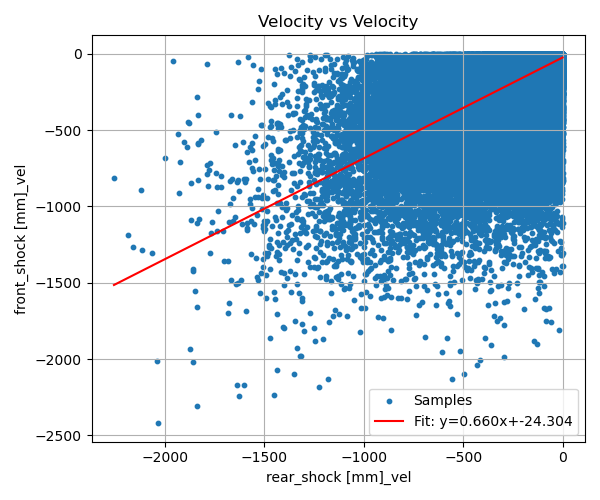

In [20]:
# === Velocity-vs-Velocity scatter with optional secondary limit ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- CONFIG -----
PRIMARY_VEL   = "rear_shock [mm]_vel"   # x-axis
SECONDARY_VEL = "front_shock [mm]_vel"  # y-axis
V_MIN, V_MAX  = -5000.0, 0.0           # velocity window (for filtering)
USE_ABS       = False                   # if True, apply limits to |vel|
LIMIT_SECONDARY = True                  # if True, also constrain secondary to [V_MIN, V_MAX]
POINT_SIZE    = 10                      # scatter marker size
# ------------------

# 0) Guards
for col in (PRIMARY_VEL, SECONDARY_VEL):
    if col not in data.columns:
        raise ValueError(f"Missing column: {col!r}")

# 1) Build mask
x_all = data[PRIMARY_VEL].astype(float).to_numpy()
y_all = data[SECONDARY_VEL].astype(float).to_numpy()

finite_mask = np.isfinite(x_all) & np.isfinite(y_all)

if USE_ABS:
    x_within = (np.abs(x_all) >= V_MIN) & (np.abs(x_all) <= V_MAX)
    if LIMIT_SECONDARY:
        y_within = (np.abs(y_all) >= V_MIN) & (np.abs(y_all) <= V_MAX)
    else:
        y_within = np.ones_like(y_all, dtype=bool)
else:
    x_within = (x_all >= V_MIN) & (x_all <= V_MAX)
    if LIMIT_SECONDARY:
        y_within = (y_all >= V_MIN) & (y_all <= V_MAX)
    else:
        y_within = np.ones_like(y_all, dtype=bool)

mask = finite_mask & x_within & y_within

x = x_all[mask]
y = y_all[mask]

n_total = len(data)
n_kept  = int(mask.sum())

print(f"Filtered {n_kept} / {n_total} samples "
      f"({(n_kept / n_total * 100 if n_total else 0):.2f}%) "
      f"with {('abs(' if USE_ABS else '')}{PRIMARY_VEL}{(')' if USE_ABS else '')} "
      f"in [{V_MIN}, {V_MAX}]"
      f"{' and secondary limited' if LIMIT_SECONDARY else ''}")

if len(x) < 2:
    raise RuntimeError("Not enough points after filtering to fit a line.")

# 2) Fit line y = m x + b
fit_info = {}
try:
    from scipy.stats import linregress
    res = linregress(x, y)
    m, b = res.slope, res.intercept
    r2 = res.rvalue**2 if np.isfinite(res.rvalue) else np.nan
    fit_info.update({"method": "scipy.stats.linregress", "slope": m, "intercept": b, "r2": r2})
except Exception:
    m, b = np.polyfit(x, y, 1)
    y_hat = m * x + b
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    fit_info.update({"method": "numpy.polyfit", "slope": m, "intercept": b, "r2": r2})

print(f"Fit method: {fit_info['method']}")
print(f"slope (m):     {fit_info['slope']:.6g}")
print(f"intercept (b): {fit_info['intercept']:.6g}")
print(f"R²:            {fit_info['r2']:.6f}")

# 3) Plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=POINT_SIZE, label="Samples")
x_fit = np.linspace(np.min(x), np.max(x), 100)
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color="red", label=f"Fit: y={m:.3f}x+{b:.3f}")
plt.xlabel(PRIMARY_VEL)
plt.ylabel(SECONDARY_VEL)
plt.title("Velocity vs Velocity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally expose for later use
velvel_fit = fit_info


## Velocity histogram

=== Velocity Statistics (post-filter) ===

rear_shock [mm]_vel:
  count   : 285644.000
  mean    :   -161.668
  median  :    -97.603
  std     :    185.253
  min     :  -2542.459
  max     :     -5.001

front_shock [mm]_vel:
  count   : 237249.000
  mean    :   -174.860
  median  :   -106.948
  std     :    199.588
  min     :  -2419.666
  max     :     -5.001


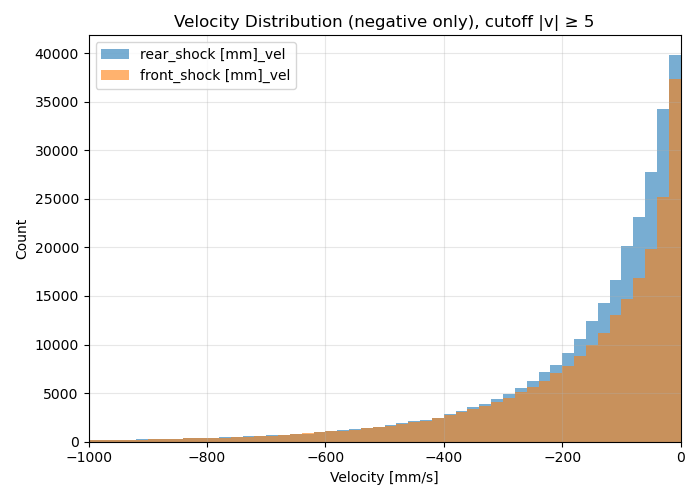

In [21]:
# === Velocity histograms (primary + secondary) with polarity & cutoff, shared bins, stats ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- CONFIG -----
DF              = data_active                  # pick your input frame
PRIMARY_VEL     = "rear_shock [mm]_vel"
SECONDARY_VEL   = "front_shock [mm]_vel"
BINS            = 50                   # number of bins
RANGE_MM_S      = (-1000,0)                  # (min, max) or None to auto based on filtered data
SHOW            = "negative"                # "both", "positive", or "negative"
CUTOFF_ABS      = 5                   # exclude samples where |velocity| < CUTOFF_ABS
DENSITY         = False                  # True -> normalized density, False -> raw counts
ALPHA           = 0.6                   # histogram transparency
# ------------------

# Guards
if not isinstance(DF, pd.DataFrame):
    raise TypeError("DF must be a pandas DataFrame (e.g., data or data_va_active).")
for col in (PRIMARY_VEL, SECONDARY_VEL):
    if col not in DF.columns:
        raise ValueError(f"Missing column: {col!r}")

# Extract series independently (histograms don't need paired samples)
x_all = DF[PRIMARY_VEL].astype(float).to_numpy()
y_all = DF[SECONDARY_VEL].astype(float).to_numpy()
x_all = x_all[np.isfinite(x_all)]
y_all = y_all[np.isfinite(y_all)]

show = SHOW.lower().strip()
cut = float(CUTOFF_ABS)

def _apply_filters(arr, show, cut):
    if show == "positive":
        arr = arr[(arr > 0) & (np.abs(arr) >= cut)]
    elif show == "negative":
        arr = arr[(arr < 0) & (np.abs(arr) >= cut)]
    else:
        arr = arr[np.abs(arr) >= cut]
    return arr

x = _apply_filters(x_all, show, cut)
y = _apply_filters(y_all, show, cut)

if len(x) == 0 or len(y) == 0:
    raise RuntimeError("No samples left after filtering; adjust SHOW/RANGE_MM_S/CUTOFF_ABS.")

# Stats after filtering
def _stats(arr):
    return {
        "count": len(arr),
        "mean": float(np.nanmean(arr)) if len(arr) else np.nan,
        "median": float(np.nanmedian(arr)) if len(arr) else np.nan,
        "std": float(np.nanstd(arr, ddof=1)) if len(arr) > 1 else np.nan,
        "min": float(np.nanmin(arr)) if len(arr) else np.nan,
        "max": float(np.nanmax(arr)) if len(arr) else np.nan,
    }
stats_primary   = _stats(x)
stats_secondary = _stats(y)

print("=== Velocity Statistics (post-filter) ===")
for name, st in ((PRIMARY_VEL, stats_primary), (SECONDARY_VEL, stats_secondary)):
    print(f"\n{name}:")
    for k in ("count","mean","median","std","min","max"):
        v = st[k]
        print(f"  {k:<8s}: {v:10.3f}" if np.isfinite(v) else f"  {k:<8s}:        nan")

# Common bins
if RANGE_MM_S is None:
    # Auto: span the filtered data, ensure zero is included and acts as a bound for single polarity
    lo = min(np.min(x), np.min(y))
    hi = max(np.max(x), np.max(y))
    # pad by 5% for aesthetics
    span = hi - lo if np.isfinite(hi - lo) and (hi - lo) > 0 else 1.0
    lo -= 0.05 * span
    hi += 0.05 * span
    # enforce zero bound behavior
    if show == "positive":
        lo = 0.0
    elif show == "negative":
        hi = 0.0
    bins = np.linspace(lo, hi, BINS + 1)
else:
    lo, hi = RANGE_MM_S
    if show == "positive":
        lo = 0.0
    elif show == "negative":
        hi = 0.0
    bins = np.linspace(lo, hi, BINS + 1)

# Plot
plt.figure(figsize=(7, 5))
plt.hist(x, bins=bins, density=DENSITY, alpha=ALPHA, label=PRIMARY_VEL)
plt.hist(y, bins=bins, density=DENSITY, alpha=ALPHA, label=SECONDARY_VEL)

plt.xlabel("Velocity [mm/s]")
plt.ylabel("Density" if DENSITY else "Count")

title_suffix = (
    " (positive only)" if show == "positive"
    else " (negative only)" if show == "negative"
    else " (all velocities)"
)
cut_text = f", cutoff |v| ≥ {CUTOFF_ABS:g}" if CUTOFF_ABS > 0 else ""
plt.title(f"Velocity Distribution{title_suffix}{cut_text}")
plt.legend()
plt.grid(True, alpha=0.3)

# Axis: ensure zero is a hard bound for single-polarity modes
xmin, xmax = bins[0], bins[-1]
if show == "positive":
    plt.xlim(left=0.0, right=xmax)
elif show == "negative":
    plt.xlim(left=xmin, right=0.0)
else:
    plt.xlim(left=xmin, right=xmax)

plt.tight_layout()
plt.show()

# Optional: expose arrays & stats
vel_hist_stats = {
    "bins": bins,
    "primary_counts": np.histogram(x, bins=bins, density=DENSITY)[0],
    "secondary_counts": np.histogram(y, bins=bins, density=DENSITY)[0],
    "stats": {
        "primary": stats_primary,
        "secondary": stats_secondary,
    },
    "config": {
        "show": show,
        "cutoff_abs": CUTOFF_ABS,
        "density": DENSITY,
        "bins_n": BINS,
        "range": (bins[0], bins[-1]),
        "primary_col": PRIMARY_VEL,
        "secondary_col": SECONDARY_VEL,
        "source_rows": len(DF),
    }
}
